# **EDA: DATASET UCI CONDITION MONITORING OF HYDRAULIC SYSTEMS**

## **LIBRERÍAS IMPORTADAS**

In [1]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import math
import warnings
warnings.filterwarnings('ignore')

## **DOCUMENTACION DEL DATASET: Condition Monitoring of Hydraulic Systems**

El Mapeo Visual: Del Banco Hidráulico al Pasteurizador en el diagrama del paper (Fig 2):

* **Circuito A (Working Circuit - Presión Alta)**: Tiene la bomba principal (MP1) y la válvula de carga (V11).
  * Analogía: Esto representa la Línea de Flujo de Producto (Leche). Aquí es donde ocurre el transporte, la presurización y el "atasco" (fouling).

* **Circuito B (Cooling Circuit - Presión Baja)**: Tiene el intercambiador de calor (C1).
  * Analogía: Esto representa la Transferencia Térmica en las Placas (PHE).

### **1. Resumen del Dataset**

El conjunto de datos se obtuvo experimentalmente mediante un **banco de pruebas hidráulico**. Este banco de pruebas consta de un circuito primario de trabajo y un circuito secundario de **refrigeración y filtrado**, los cuales están conectados a través del **depósito de aceite**. El sistema repite cíclicamente **ciclos** de carga constantes (de **60 segundos** de duración) y mide valores del proceso como **presiones, caudales volumétricos y temperaturas**, mientras se varía cuantitativamente el estado de **cuatro componentes hidráulicos (enfriador, válvula, bomba y acumulador)**.

El objetivo es predecir el estado de estos componentes basándose en las lecturas de los sensores.



---

### **2. Información del Dataset**

| Característica | Detalle |
| :--- | :--- |
| **Instancias (Ciclos)** | 2.205 ciclos |
| **Duración del ciclo** | 60 segundos |
| **Atributos (Total)** | 43.680 por fila (debido a las altas tasas de muestreo) |
| **Valores faltantes** | Ninguno |
| **Tipo de Tarea** | Clasificación (Diagnóstico) o Regresión (Estimación de salud) |

---

### **3. Atributos (Sensores / Features)**
Los datos brutos de los sensores están estructurados en archivos de texto separados (matrices), donde las filas representan los ciclos y las columnas los puntos de datos dentro del ciclo.

| Sensor | Cantidad Física | Unidad | Frecuencia | Puntos por Ciclo | Descripción |
| :--- | :--- | :--- | :--- | :--- | :--- |
| **PS1** | Presión | bar | 100 Hz | 6000 | Presión del sistema |
| **PS2** | Presión | bar | 100 Hz | 6000 | Presión |
| **PS3** | Presión | bar | 100 Hz | 6000 | Presión |
| **PS4** | Presión | bar | 100 Hz | 6000 | Presión |
| **PS5** | Presión | bar | 100 Hz | 6000 | Presión |
| **PS6** | Presión | bar | 100 Hz | 6000 | Presión |
| **EPS1** | Potencia Motor | W | 100 Hz | 6000 | Potencia eléctrica |
| **FS1** | Caudal Volumétrico | L/min | 10 Hz | 600 | Flujo de aceite |
| **FS2** | Caudal Volumétrico | L/min | 10 Hz | 600 | Flujo de aceite |
| **TS1** | Temperatura | °C | 1 Hz | 60 | Temperatura del tanque |
| **TS2** | Temperatura | °C | 1 Hz | 60 | Temperatura |
| **TS3** | Temperatura | °C | 1 Hz | 60 | Temperatura |
| **TS4** | Temperatura | °C | 1 Hz | 60 | Temperatura |
| **VS1** | Vibración | mm/s | 1 Hz | 60 | Vibración mecánica |
| **CE** | Eficiencia Enfriamiento| % | 1 Hz | 60 | Sensor virtual |
| **CP** | Potencia Enfriamiento | kW | 1 Hz | 60 | Sensor virtual |
| **SE** | Factor Eficiencia | % | 1 Hz | 60 | Sensor virtual |

---

### **4. Etiquetas (Targets / Outputs)**
Las condiciones de los componentes se encuentran en el archivo `profile.txt`. Cada fila corresponde a un ciclo.

#### **A. Estado del Enfriador (Cooler_Condition)**
| Valor | Significado | Instancias |
| :--- | :--- | :--- |
| **3** | Casi fallo total | 732 |
| **20** | Eficiencia reducida | 732 |
| **100** | Eficiencia total (Sano) | 741 |

#### **B. Estado de la Válvula (Valve_Condition)**
| Valor | Significado | Instancias |
| :--- | :--- | :--- |
| **100** | Comportamiento óptimo | 1125 |
| **90** | Pequeño retraso (Small lag) | 360 |
| **80** | Retraso severo (Severe lag) | 360 |
| **73** | Casi fallo total | 360 |

#### **C. Fuga Interna de la Bomba (Pump_Leakage)**
| Valor | Significado | Instancias |
| :--- | :--- | :--- |
| **0** | Sin fugas | 1221 |
| **1** | Fuga débil | 492 |
| **2** | Fuga severa | 492 |

#### **D. Acumulador Hidráulico (Hydraulic_Accumulator)**
| Valor | Significado | Instancias |
| :--- | :--- | :--- |
| **130** | Presión óptima (bar) | 599 |
| **115** | Presión ligeramente reducida | 399 |
| **100** | Presión severamente reducida | 399 |
| **90** | Casi fallo total | 808 |

#### **E. Bandera de Estabilidad (Stable_Flag)**
| Valor | Significado | Instancias |
| :--- | :--- | :--- |
| **0** | Condiciones estables | 1449 |
| **1** | Condiciones estáticas no alcanzadas | 756 |

---

### **5. Fuente y Citas**
**Creador:** Nikolai Helwig, ZeMA gGmbH, Saarbrücken.  
**Donantes:** M. Bastuck, T. Schneider.  
**Fecha:** Abril, 2018.

**Papers Relevantes:**
> [1] Nikolai Helwig, Eliseo Pignanelli, Andreas Schütze, ‘Condition Monitoring of a Complex Hydraulic System Using Multivariate Statistics’, in Proc. I2MTC-2015. doi: 10.1109/I2MTC.2015.7151267

## **IMPORTACIÓN DE LOS DATOS**

In [2]:
# Detectamos el directorio actual (donde está el notebook)
current_dir = os.getcwd()

# Definimos la ruta relativa a los datos.
# Si el notebook está en una carpeta 'notebooks', subimos un nivel (..) y entramos a data
ruta_datos = os.path.join(current_dir, '..', '..', 'data', 'raw', 'Dataset_Hydraulic')

# Normalizamos la ruta (quita los ".." y deja la ruta absoluta limpia)
ruta_datos = os.path.normpath(ruta_datos)

# DEFINIR NOMBRES DE ARCHIVOS Y SENSORES
# Nombres de los archivos físicos (sin el .txt)
nombres_sensores = [
    'PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', # Presión (100 Hz)
    'EPS1',                                   # Potencia Motor (100 Hz)
    'FS1', 'FS2',                             # Flujo Volumen (10 Hz)
    'TS1', 'TS2', 'TS3', 'TS4',               # Temperatura (1 Hz)
    'VS1',                                    # Vibración (1 Hz)
    'CE', 'CP', 'SE'                          # Sensores virtuales (1 Hz)
]

# CARGAR LAS ETIQUETAS (PROFILE.TXT)
# Estas son tus variables objetivo (los que no son sensores)
print("Cargando profile.txt...")
df_completo = pd.read_csv(os.path.join(ruta_datos, 'profile.txt'), sep='\t', header=None)
df_completo.columns = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator', 'Stable_Flag']

# CARGAR Y FUSIONAR CADA SENSOR
for sensor in nombres_sensores:
    archivo = os.path.join(ruta_datos, f'{sensor}.txt')
    print(f"Procesando {sensor}...")
    
    # Cargar el archivo del sensor (delimitado por tabulaciones)
    df_temporal = pd.read_csv(archivo, sep='\t', header=None)
    
    # Renombrar las columnas para evitar colisiones y saber el tiempo
    df_temporal.columns = [f'{sensor}_{i}' for i in range(df_temporal.shape[1])]
    
    # Concatenar horizontalmente (axis=1) al DataFrame principal
    df_completo = pd.concat([df_completo, df_temporal], axis=1)

print("¡Importación completada!")
print(f"Dimensiones finales: {df_completo.shape}") 
# Debería ser (2205, 43685) -> 43680 datos + 5 etiquetas

Cargando profile.txt...
Procesando PS1...
Procesando PS2...
Procesando PS3...
Procesando PS4...
Procesando PS5...
Procesando PS6...
Procesando EPS1...
Procesando FS1...
Procesando FS2...
Procesando TS1...
Procesando TS2...
Procesando TS3...
Procesando TS4...
Procesando VS1...
Procesando CE...
Procesando CP...
Procesando SE...
¡Importación completada!
Dimensiones finales: (2205, 43685)


In [3]:
n_ciclos = 2205
n_puntos_por_ciclo = 6000 # 100 Hz * 60 segundos
n_total_filas = n_ciclos * n_puntos_por_ciclo # 13,230,000 filas

print(f"Preparando DataFrame de {n_total_filas:,} filas.")

# 1. CREAR ÍNDICES MAESTROS (Ciclo y Tiempo)
cycle_ids = np.repeat(np.arange(n_ciclos), n_puntos_por_ciclo)
time_axis = np.tile(np.arange(0, 60, 0.01), n_ciclos)

# Creamos el diccionario inicial con los índices
data_dict = {
    'Cycle_ID': cycle_ids,
    'Time': time_axis
}

# 2. DEFINIMOS SENSORES Y SU FRECUENCIA ORIGINAL
sensores_config = {
    'PS1': 100, 'PS2': 100, 'PS3': 100, 'PS4': 100, 'PS5': 100, 'PS6': 100, 'EPS1': 100,
    'FS1': 10, 'FS2': 10,
    'TS1': 1, 'TS2': 1, 'TS3': 1, 'TS4': 1, 'VS1': 1, 'CE': 1, 'CP': 1, 'SE': 1
}

# 3. PROCESAR SENSORES
for sensor, freq in sensores_config.items():
    
    cols = [c for c in df_completo.columns if c.startswith(f"{sensor}_")]
    matriz_valores = df_completo[cols].to_numpy()
    
    if freq == 100:
        data_dict[sensor] = matriz_valores.flatten()
    else:
        factor_repeticion = 6000 // matriz_valores.shape[1]
        matriz_expandida = matriz_valores.repeat(factor_repeticion, axis=1)
        data_dict[sensor] = matriz_expandida.flatten()

# 4. PROCESAR ETIQUETAS (TARGETS)
# Las etiquetas son constantes para todo el ciclo.
targets = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator', 'Stable_Flag']

for target in targets:
    # Tomamos la columna de etiquetas (2205 valores)
    vals = df_completo[target].to_numpy()
    # Repetimos cada valor 6000 veces
    data_dict[target] = vals.repeat(n_puntos_por_ciclo)

# 5. CREAR EL DATAFRAME FINAL
df_long = pd.DataFrame(data_dict)

# Optimización de memoria: (Pasar floats a float32)
for col in df_long.select_dtypes(include=['float64']).columns:
    df_long[col] = df_long[col].astype('float32')

df = df_long

# =========================================================================
# GUARDADO DEL DATASET COMO CSV
# =========================================================================
#df.to_csv("../../data/raw/hydraulic_raw.csv", index=False)

print("¡Datos importados correctamente!")

Preparando DataFrame de 13,230,000 filas.
¡Datos importados correctamente!


**Variables que hemos introducido para la importación:**

* **Time (segundos):** Para registrar las frecuencias diferentes. 
    * 0.01 -> Sensores 1 Hz
    * 1.00 -> Sensores 100 Hz

* **Cycle_ID:** Muestra el ciclo completo en el que nos encontramos. Hay 2205 en total y cada uno dura 60 segundos.

En total tenemos registros de la máquina de: $$2205 \cdot 60 = 132.300 \,\text{segundos} = 36,75 \,\text{horas}$$

Convertimos el dataset a una serie temporal para poder trabajar de forma más efectiva:

In [4]:
#df = pd.read_csv('../../data/raw/hydraulic_raw.csv'

In [5]:
# ========================================================================
# CONVERSIÓN A SERIE TEMPORAL
# ========================================================================

# 1. Creamos la variable de tiempo continuo (Absolute_Time)
df['Absolute_Time'] = (df['Cycle_ID'] * 60) + df['Time']

# 2. Ordenamos por seguridad
df = df.sort_values('Absolute_Time').reset_index(drop=True)

# 3. Generación de fechas
start_date = pd.Timestamp("2026-01-01 00:00:00")

# Calculamos todo en MILISEGUNDOS y redondeamos al entero más cercano.
total_milliseconds = (df['Cycle_ID'] * 60000) + (df['Time'] * 1000).round()

# Convertimos usando la unidad 'ms' (milisegundos) que es exacta
df['date'] = start_date + pd.to_timedelta(total_milliseconds, unit='ms')

# 4. Verificación de limpieza
print("Verificando precisión de fechas (Primeras filas):")
print(df[['Cycle_ID', 'Time', 'date']].head())

Verificando precisión de fechas (Primeras filas):
   Cycle_ID  Time                    date
0         0  0.00 2026-01-01 00:00:00.000
1         0  0.01 2026-01-01 00:00:00.010
2         0  0.02 2026-01-01 00:00:00.020
3         0  0.03 2026-01-01 00:00:00.030
4         0  0.04 2026-01-01 00:00:00.040


## **EDA (Análisis exploratorio)**

In [6]:
# ==============================================================================
# MAPEO DE ETIQUETAS: DE HIDRÁULICA A PASTEURIZADOR
# ==============================================================================

def map_cooler_to_fouling(val):
    if val == 100: return 0     # Sano
    elif val == 20: return 1    # Advertencia
    else: return 2              # Crítico

def map_valve_to_fdv(val):
    if val == 100: return 0     # Ok
    elif val >= 80: return 1    # Lenta
    else: return 2              # Atascada

def map_pump_to_pump(val):
    if val == 0: return 0       # No leak
    elif val == 1: return 1     # Weak
    else: return 2              # Severe

def map_accumulator_to_stability(val):
    if val == 130: return 0     # Estable
    elif val >= 100: return 1   # Vibración
    else: return 2              # Inestable

# Aplicamos el mapeo sobre df:
df['Target_Fouling'] = df['Cooler_Condition'].apply(map_cooler_to_fouling)
df['Target_Valvula'] = df['Valve_Condition'].apply(map_valve_to_fdv)
df['Target_Bomba'] = df['Pump_Leakage'].apply(map_pump_to_pump)
df['Target_Acumulador'] = df['Hydraulic_Accumulator'].apply(map_accumulator_to_stability)

# Seleccionamos las columnas finales para el modelo:
cols_a_eliminar = ['Cooler_Condition', 'Valve_Condition', 'Pump_Leakage', 'Hydraulic_Accumulator']
df = df.drop(columns=cols_a_eliminar)

print("Nuevo Dataset Pasteurizador Virtual:")
display(df.head())

print("\nDistribución de tus nuevos Targets de Pasteurización:")
targets_finales = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
for t in targets_finales:
    print(df[t].value_counts(normalize=True))

Nuevo Dataset Pasteurizador Virtual:


,Cycle_ID,Time,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,...,CE,CP,SE,Stable_Flag,Absolute_Time,date,Target_Fouling,Target_Valvula,Target_Bomba,Target_Acumulador
0,0,0.00,151.470001,125.500000,2.305,0.0,9.936,9.818,2411.600098,8.99,...,47.202,2.184,68.039001,1,0.00,2026-01-01 00:00:00.000,2,0,0,0
1,0,0.01,151.449997,125.389999,2.305,0.0,9.947,9.823,2411.600098,8.99,...,47.202,2.184,68.039001,1,0.01,2026-01-01 00:00:00.010,2,0,0,0
2,0,0.02,151.520004,125.400002,2.336,0.0,9.964,9.844,2411.600098,8.99,...,47.202,2.184,68.039001,1,0.02,2026-01-01 00:00:00.020,2,0,0,0
3,0,0.03,151.270004,125.029999,2.578,0.0,9.989,9.861,2411.600098,8.99,...,47.202,2.184,68.039001,1,0.03,2026-01-01 00:00:00.030,2,0,0,0
4,0,0.04,150.800003,124.050003,2.977,0.0,9.996,9.877,2411.600098,8.99,...,47.202,2.184,68.039001,1,0.04,2026-01-01 00:00:00.040,2,0,0,0



Distribución de tus nuevos Targets de Pasteurización:
Target_Fouling
0    0.336054
2    0.331973
1    0.331973
Name: proportion, dtype: float64
Target_Valvula
0    0.510204
1    0.326531
2    0.163265
Name: proportion, dtype: float64
Target_Bomba
0    0.553741
2    0.223129
1    0.223129
Name: proportion, dtype: float64
Target_Acumulador
2    0.366440
1    0.361905
0    0.271655
Name: proportion, dtype: float64


De este modo, para cada una de las componentes tenemos el siguiente reparto de sus clases de fallo (en porcentaje):

**Target_Fouling**:
* **0**: 33,61 %
* **1**: 33,19 %
* **2**: 33,19 %

**Target_Valvula**:
* **0**: 51,02 %
* **1**: 32,65 %
* **2**: 16,32 %

**Target_Bomba**:
* **0**: 55,37 %
* **1**: 22,31 %
* **2**: 22,31 %

**Target_Acumulador**:
* **0**: 27,16 %
* **1**: 36,19 %
* **2**: 36,64 %

In [7]:
print("Número de filas:", df.shape[0])
print("Número de columnas:", df.shape[1])
print("Número de elementos en total:", df.size)

print("\nNúmero de filas duplicadas:")
print(df.duplicated().sum())

print("\nInformación del dataset:")
pd.set_option('display.max_columns', None)
print(df.dtypes)

print("\nNúmero de datos nulos:")
print(df.isnull().sum())

print("\nPrimeras 5 filas")
pd.set_option('display.max_columns', None)
display(df.head())

Número de filas: 13230000
Número de columnas: 26
Número de elementos en total: 343980000

Número de filas duplicadas:
0

Información del dataset:
Cycle_ID                      int64
Time                        float32
PS1                         float32
PS2                         float32
PS3                         float32
PS4                         float32
PS5                         float32
PS6                         float32
EPS1                        float32
FS1                         float32
FS2                         float32
TS1                         float32
TS2                         float32
TS3                         float32
TS4                         float32
VS1                         float32
CE                          float32
CP                          float32
SE                          float32
Stable_Flag                   int64
Absolute_Time               float64
date                 datetime64[ns]
Target_Fouling                int64
Target_Valvula            

,Cycle_ID,Time,PS1,PS2,PS3,PS4,PS5,PS6,EPS1,FS1,FS2,TS1,TS2,TS3,TS4,VS1,CE,CP,SE,Stable_Flag,Absolute_Time,date,Target_Fouling,Target_Valvula,Target_Bomba,Target_Acumulador
0,0,0.00,151.470001,125.500000,2.305,0.0,9.936,9.818,2411.600098,8.99,10.179,35.57,40.960999,38.32,30.363001,0.604,47.202,2.184,68.039001,1,0.00,2026-01-01 00:00:00.000,2,0,0,0
1,0,0.01,151.449997,125.389999,2.305,0.0,9.947,9.823,2411.600098,8.99,10.179,35.57,40.960999,38.32,30.363001,0.604,47.202,2.184,68.039001,1,0.01,2026-01-01 00:00:00.010,2,0,0,0
2,0,0.02,151.520004,125.400002,2.336,0.0,9.964,9.844,2411.600098,8.99,10.179,35.57,40.960999,38.32,30.363001,0.604,47.202,2.184,68.039001,1,0.02,2026-01-01 00:00:00.020,2,0,0,0
3,0,0.03,151.270004,125.029999,2.578,0.0,9.989,9.861,2411.600098,8.99,10.179,35.57,40.960999,38.32,30.363001,0.604,47.202,2.184,68.039001,1,0.03,2026-01-01 00:00:00.030,2,0,0,0
4,0,0.04,150.800003,124.050003,2.977,0.0,9.996,9.877,2411.600098,8.99,10.179,35.57,40.960999,38.32,30.363001,0.604,47.202,2.184,68.039001,1,0.04,2026-01-01 00:00:00.040,2,0,0,0


No hay nulos y todas las variables son numéricas, por lo que podremos realizar análisis de correlación sin problema. 

### **Desbalanceo de clases**

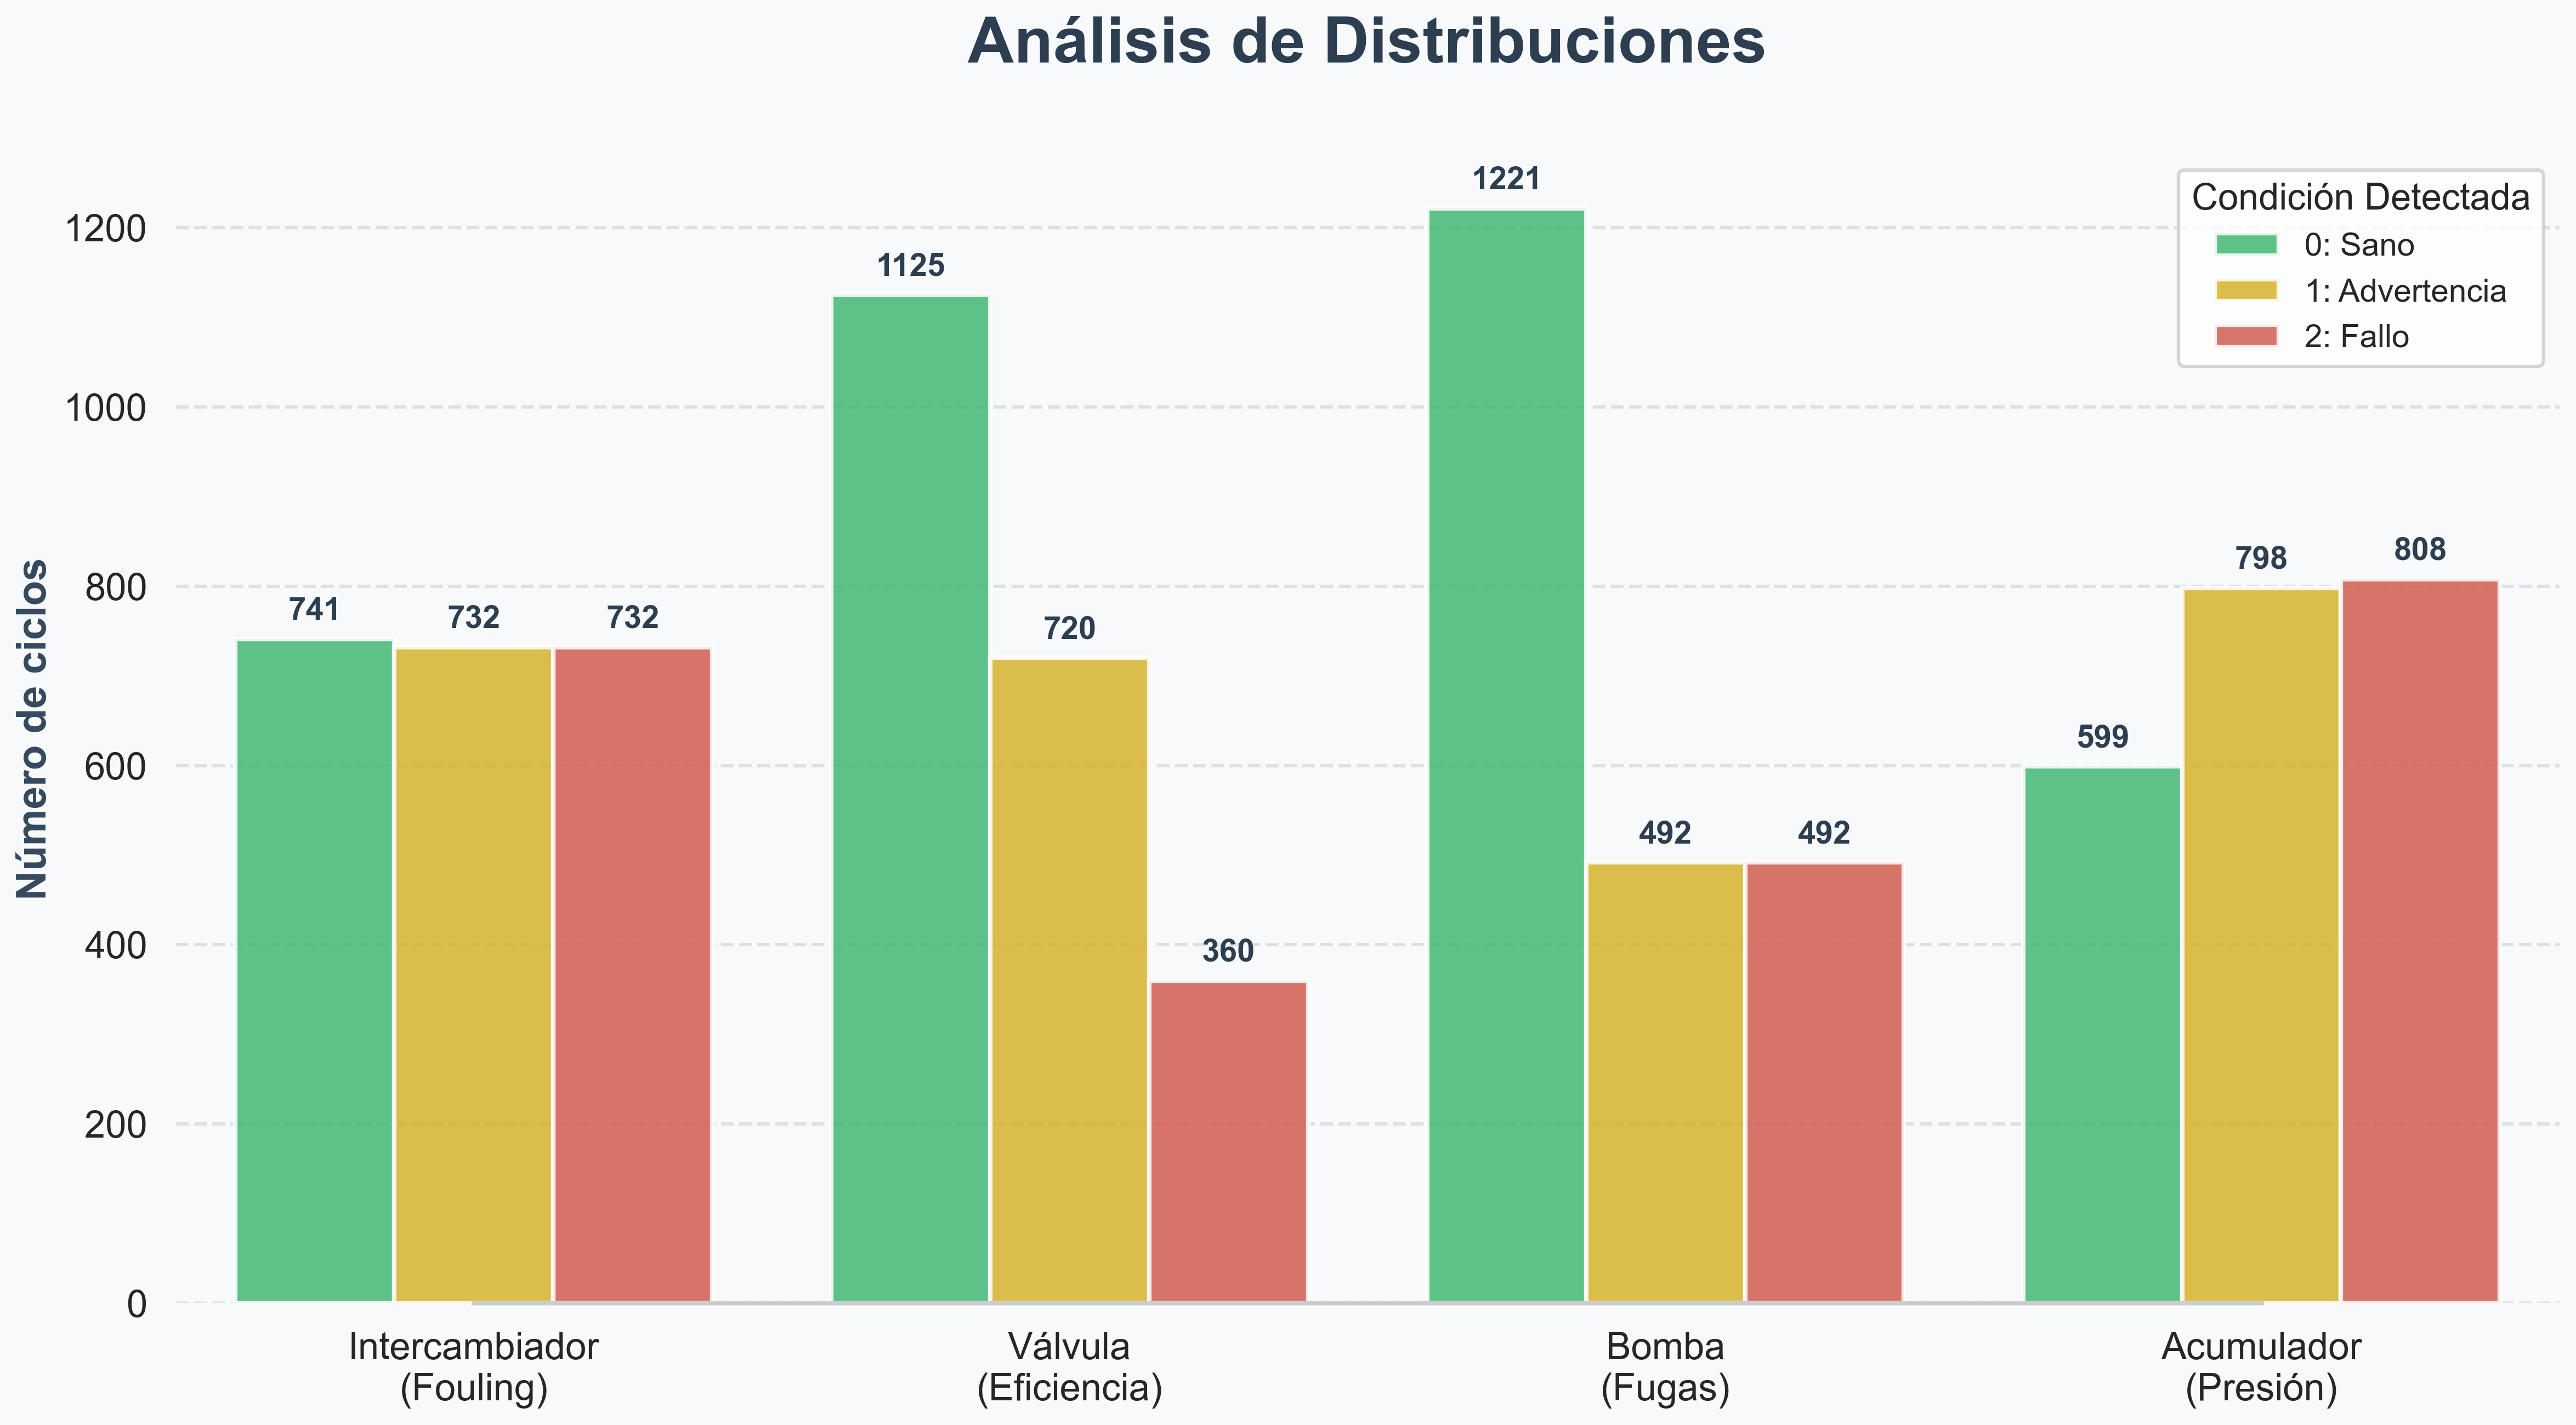

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
import pandas as pd

# 1. Configuración de alta resolución y tipografía
# Puedes cambiar 'DejaVu Sans' por 'Arial' o 'Roboto' si lo tienes instalado
plt.rcParams['figure.dpi'] = 300
plt.rcParams['savefig.dpi'] = 300
sns.set_context("talk") # Ajusta automáticamente grosores para que se vea "pro"

# 2. Preparación y Mapeo de Datos (Semántica)
targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador']
df_ciclos_unicos = df.drop_duplicates('Cycle_ID')

df_plot = df_ciclos_unicos.melt(value_vars=targets, var_name='Componente', value_name='Estado')

# Mapeo de nombres de componentes y estados (Basado en la lógica del proyecto)
comp_map = {
    'Target_Fouling': 'Target Fouling',
    'Target_Valvula': 'Target Valcula',
    'Target_Bomba': 'Bomba\n(Fugas)',
    'Target_Acumulador': 'Acumulador\n(Presión)'
}
state_map = {0: '0: Sano', 1: '1: Advertencia', 2: '2: Fallo'}

df_plot['Componente'] = df_plot['Componente'].map(comp_map)
df_plot['Estado'] = df_plot['Estado'].map(state_map)

# 3. Creación del Lienzo
fig, ax = plt.subplots(figsize=(16, 9), facecolor='#F8F9FA')
ax.set_facecolor('#F8F9FA')

# 4. Gráfico con paleta técnica (Colorblind friendly)
colors = ["#2ECC71", "#F1C40F", "#E74C3C"] # Verde, Amarillo, Rojo
sns.countplot(
    data=df_plot, 
    x='Componente', 
    hue='Estado', 
    hue_order=['0: Sano', '1: Advertencia', '2: Fallo'],
    palette=colors,
    edgecolor="white",
    linewidth=2,
    alpha=0.85,
    ax=ax
)

# 5. Refinamiento de Ejes y Títulos
ax.set_title('Análisis de Distribuciones', fontsize=28, fontweight='bold', pad=40, color='#2C3E50')
ax.set_xlabel('', fontsize=20) # El eje X se explica solo con las etiquetas de los componentes
ax.set_ylabel('Número de ciclos', fontsize=18, fontweight='bold', color='#34495E')

# Cuadrícula sutil solo en el eje Y
ax.yaxis.grid(True, linestyle='--', which='major', color='grey', alpha=0.2)
sns.despine(trim=True, left=True) # Estética minimalista

# 6. Etiquetas de datos premium
for p in ax.patches:
    if p.get_height() > 0:
        ax.annotate(f'{int(p.get_height())}', 
                    (p.get_x() + p.get_width() / 2., p.get_height()), 
                    ha='center', va='center', 
                    xytext=(0, 12), textcoords='offset points',
                    fontsize=14, fontweight='bold', color='#2C3E50')

# 7. Leyenda posicionada estratégicamente
ax.legend(title='Condición Detectada', title_fontsize=16, fontsize=14, loc='upper right', frameon=True, facecolor='white')

plt.tight_layout()

# Opcional: Guardar en alta calidad
# plt.savefig('distribucion_estados_47.png', bbox_inches='tight', transparent=False)

plt.show()


No hay desbalanceo de clases, de hecho, hay muchos registros de anomalías y fallos en la maquinaria.

### **Mapa de calor (Correlaciones)**

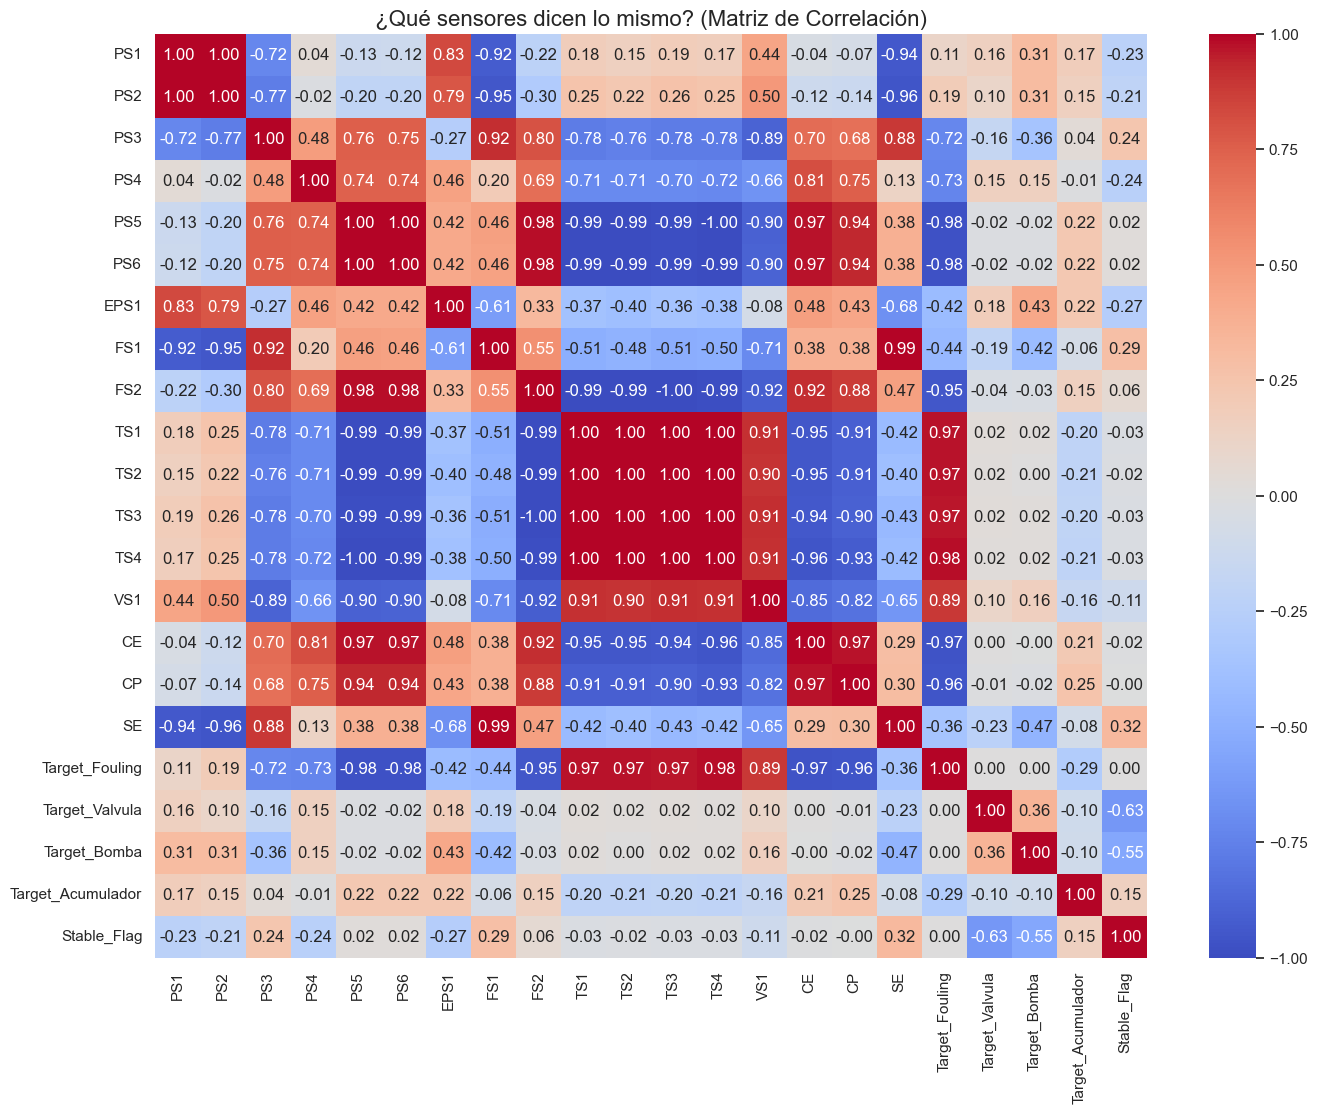

In [ ]:
# 1. Agrupamos por ciclo para aligerar la carga (de 13M de filas a 2205)
# Esto nos da el comportamiento "promedio" de cada ciclo
df_resumen = df.groupby('Cycle_ID').mean(numeric_only=True)

# 2. Seleccionamos solo los sensores para la correlación
cols_sensores = ['PS1', 'PS2', 'PS3', 'PS4', 'PS5', 'PS6', 'EPS1', 
                 'FS1', 'FS2', 'TS1', 'TS2', 'TS3', 'TS4', 'VS1', 'CE', 'CP', 'SE']
    
cols_targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador', 'Stable_Flag']

corr_matrix = df_resumen[cols_sensores + cols_targets].corr()

# 3. Graficamos
plt.figure(figsize=(16, 12))
sns.heatmap(corr_matrix, annot=True, fmt=".2f", cmap="coolwarm", vmin=-1, vmax=1)
plt.title("¿Qué sensores dicen lo mismo? (Matriz de Correlación)", fontsize=16)
plt.show()

**RESULTADOS DE LAS CORRELACIONES DE LOS SENSORES:**

* **PS1 y PS2** tienen correlación 1.
* **PS5 y PS6** tienen correlación 1.
* **TS1, TS2, TS3 y TS4** tienen correlación 1.
* **FS2 y TS1 y PS5** tienen correlación 1.

De este modo, nos quedamos con:
* **PS1**: Presión de entrada
* **PS3**: Presión de salida
* **EPS1**: Potencia Motor
* **FS1**: Caudal / Flujo salida
* **TS1 y TS2**: Temperatura entrada y salida. Aunque presentan colinealidad las transformaremos haciendo uso del dataset "Heat Exchanger".
* **VS1**: Vibración del tubo de entrada

### **VARIABLES NECESARIAS:**

**Del Circuito A (Línea de Producto / Bombeo):** Se deben coger estos sensores para simular la Hidráulica y el Fouling Mecánico:

* PS1 (Presión tras la bomba): Presión de Entrada al Intercambiador. Si hay fouling (suciedad), esta presión sube. Es el sensor más importante.
* PS2 (Presión tras la válvula): Presión de Salida / Retorno. La diferencia PS1 - PS2 es el Delta P. Si el Delta P aumenta, significa que las placas están sucias.
* EPS1 (Potencia Motor MP1): Amperaje de la Bomba de Alimentación. Si la bomba cavita o se desgasta, se verá que consume energía pero no mueve fluido correctamente.
* FS1 (Caudal Principal): Caudal de Leche (L/h). Fundamental para calcular el tiempo de residencia en el tubo de mantenimiento.
* VS1 (Vibración): Vibración del Homogeneizador. Los homogeneizadores son pistones mecánicos que vibran mucho cuando fallan. Este sensor da realismo al mantenimiento predictivo mecánico.

* **Del Circuito B (Intercambio Térmico):** Se debe coger estos sensores para simular la Termodinámica y Seguridad Alimentaria:

* TS1 (Temperatura Tanque/Entrada): Temperatura Leche Cruda (Entrada).
* TS2 (Temperatura Sistema): Temperatura de Pasteurización (Salida).

La relación entre TS1 y TS2 dice si el intercambiador funciona. Si el "Cooler" falla en el dataset hidráulico (target Cooler_Condition), la diferencia de temperatura cambia. Eso es exactamente lo que pasa cuando hay fouling en un pasteurizador.

### **VARIABLES A DESCARTAR:**

El paper menciona que usan acumuladores (A1-A4) con diferentes presiones de precarga para simular cargas dinámicas.

* Hay que descartar: PS3, PS4, PS5, PS6. Son presiones intermedias de los acumuladores. En un pasteurizador no hay 4 acumuladores conmutables. Con tener la presión de entrada (PS1) y salida (PS2) es suficiente para caracterizar el sistema.

* Hay que descartar FS2: Es redundante con FS1.

### **SELECCIÓN DE CARACTERISTICAS**

In [ ]:
# Definimos los sensores ganadores según el análisis
sensores_finales = ['PS1', 'PS2', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1', 'CE', 'CP', 'SE']
targets = ['Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador', 'Stable_Flag']
cols_id = ['Cycle_ID', 'Time', 'Absolute_Time', 'date']     # Mantenemos los índices

# Filtramos el DataFrame
df_clean = df[cols_id + sensores_finales + targets].copy()

print(f"Dataset reducido. Columnas actuales: {len(df_clean.columns)}")
print(df_clean.columns.tolist())

Dataset reducido. Columnas actuales: 19
['Cycle_ID', 'Time', 'Absolute_Time', 'date', 'PS1', 'PS2', 'EPS1', 'FS1', 'TS1', 'TS2', 'VS1', 'CE', 'CP', 'SE', 'Target_Fouling', 'Target_Valvula', 'Target_Bomba', 'Target_Acumulador', 'Stable_Flag']


### **GRÁFICOS EN FUNCIÓN DEL TIEMPO**

Graficando 15 variables...


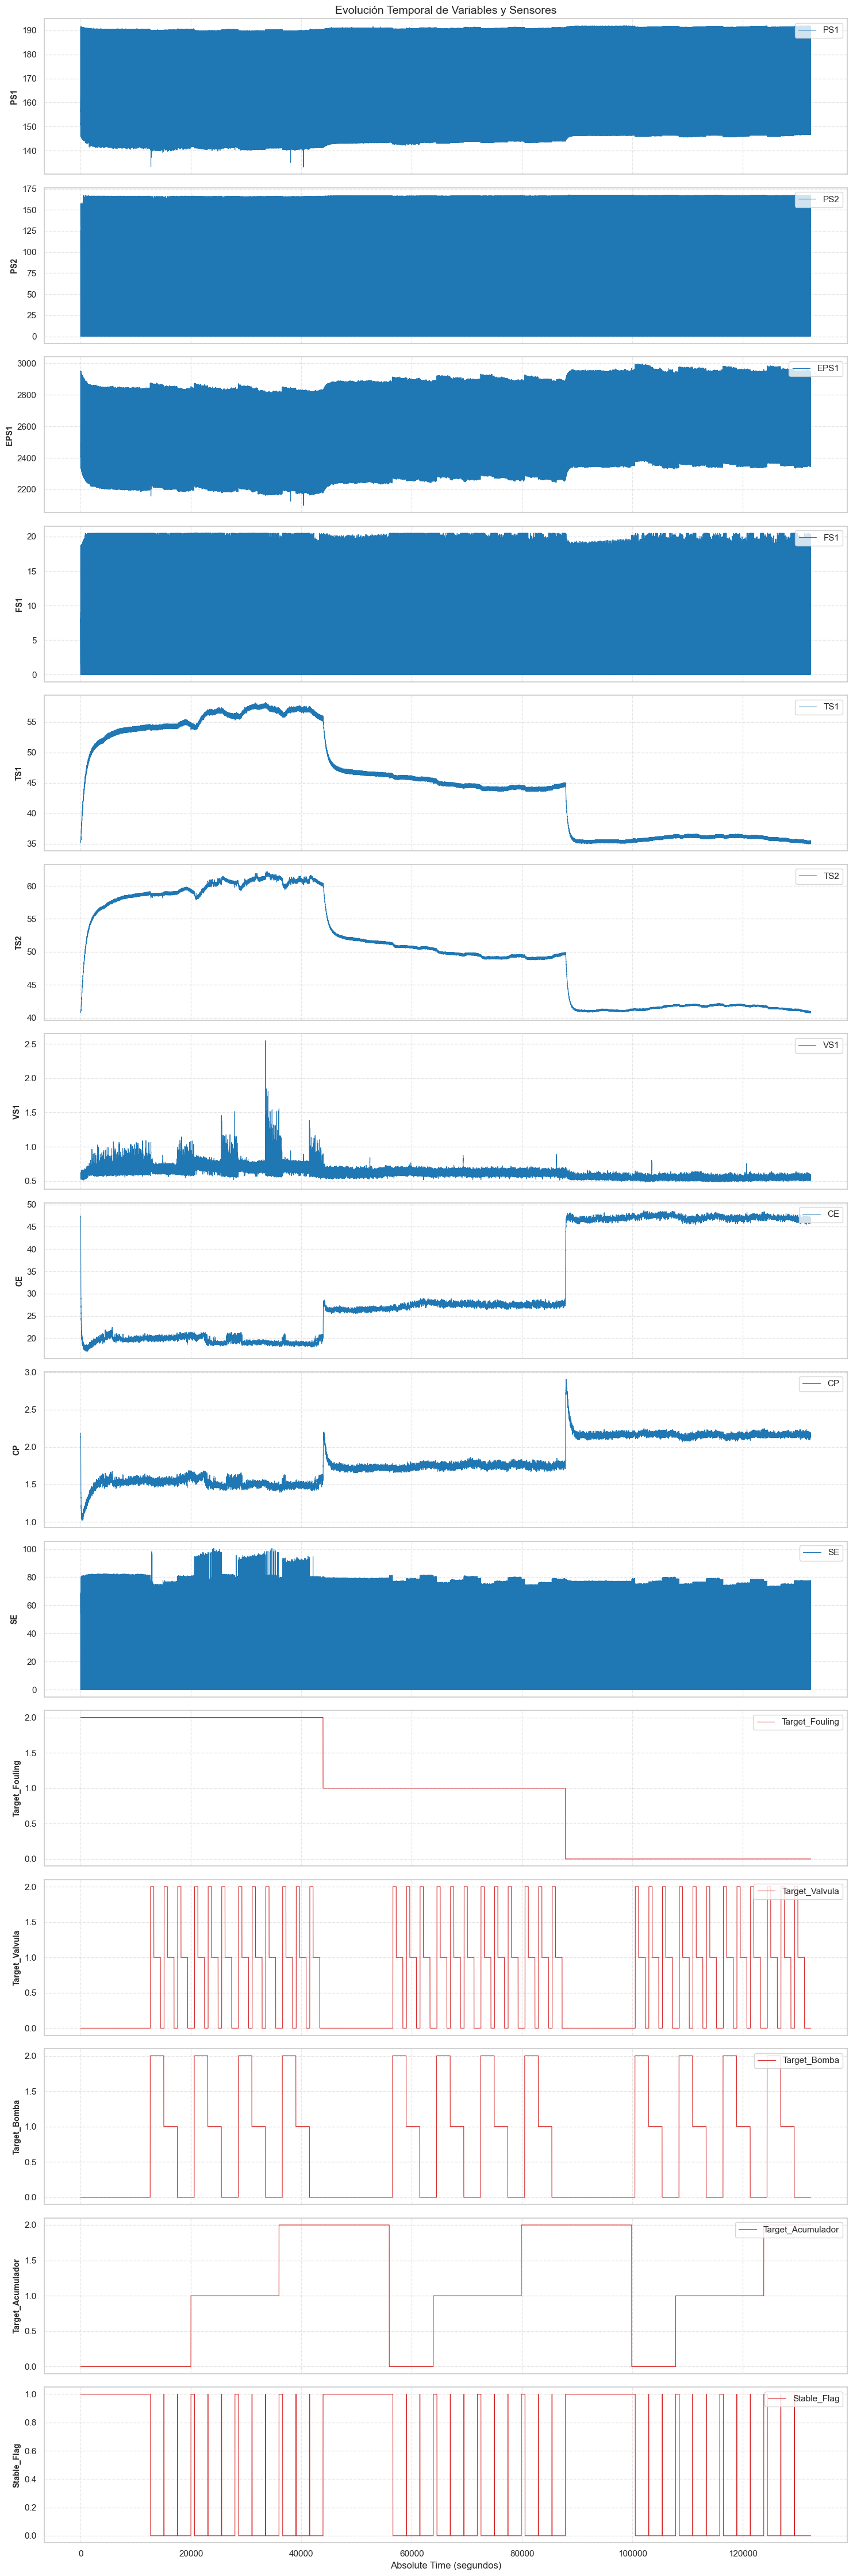

In [ ]:
# Definir columnas a graficar (Excluyendo las columnas de tiempo e índices)
cols_exclude = ['Cycle_ID', 'Time', 'Absolute_Time', 'date']
cols_to_plot = sensores_finales + targets
n_plots = len(cols_to_plot)

df_vis = df.copy()

# Configuración del plot
# Ajustamos el alto de la figura en función del número de variables
fig, axes = plt.subplots(n_plots, 1, figsize=(15, 3 * n_plots), sharex=True)

# Manejo de caso borde si solo hubiera 1 columna
if n_plots == 1:
    axes = [axes]

# Generación de los gráficos
print(f"Graficando {n_plots} variables...")

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # Diferenciar color si es Sensor (azul) o Target (rojo/naranja)
    color = 'tab:blue' if col in sensores_finales else 'tab:red'
    
    ax.plot(df_vis['Absolute_Time'], df_vis[col], label=col, color=color, linewidth=0.8)
    
    ax.set_ylabel(col, fontsize=10, fontweight='bold')
    ax.legend(loc='upper right')
    ax.grid(True, linestyle='--', alpha=0.5)
    
    # Solo ponemos título en la primera y etiqueta X en la última
    if i == 0:
        ax.set_title('Evolución Temporal de Variables y Sensores', fontsize=14)
    if i == n_plots - 1:
        ax.set_xlabel('Absolute Time (segundos)', fontsize=12)

plt.tight_layout()
plt.show()

Los sensores tienen comportamiento oscilatorio o similar entre ellos. Sin embargo, los targets presentan comportamientos demasiado artificiales (es normal al ser datos sintéticos). Aún así, tenemos que examinar diferentes factores para ver si es de utilidad este conjunto de datos.

### **DISTRIBUCIONES**

Generando distribuciones para 10 variables...


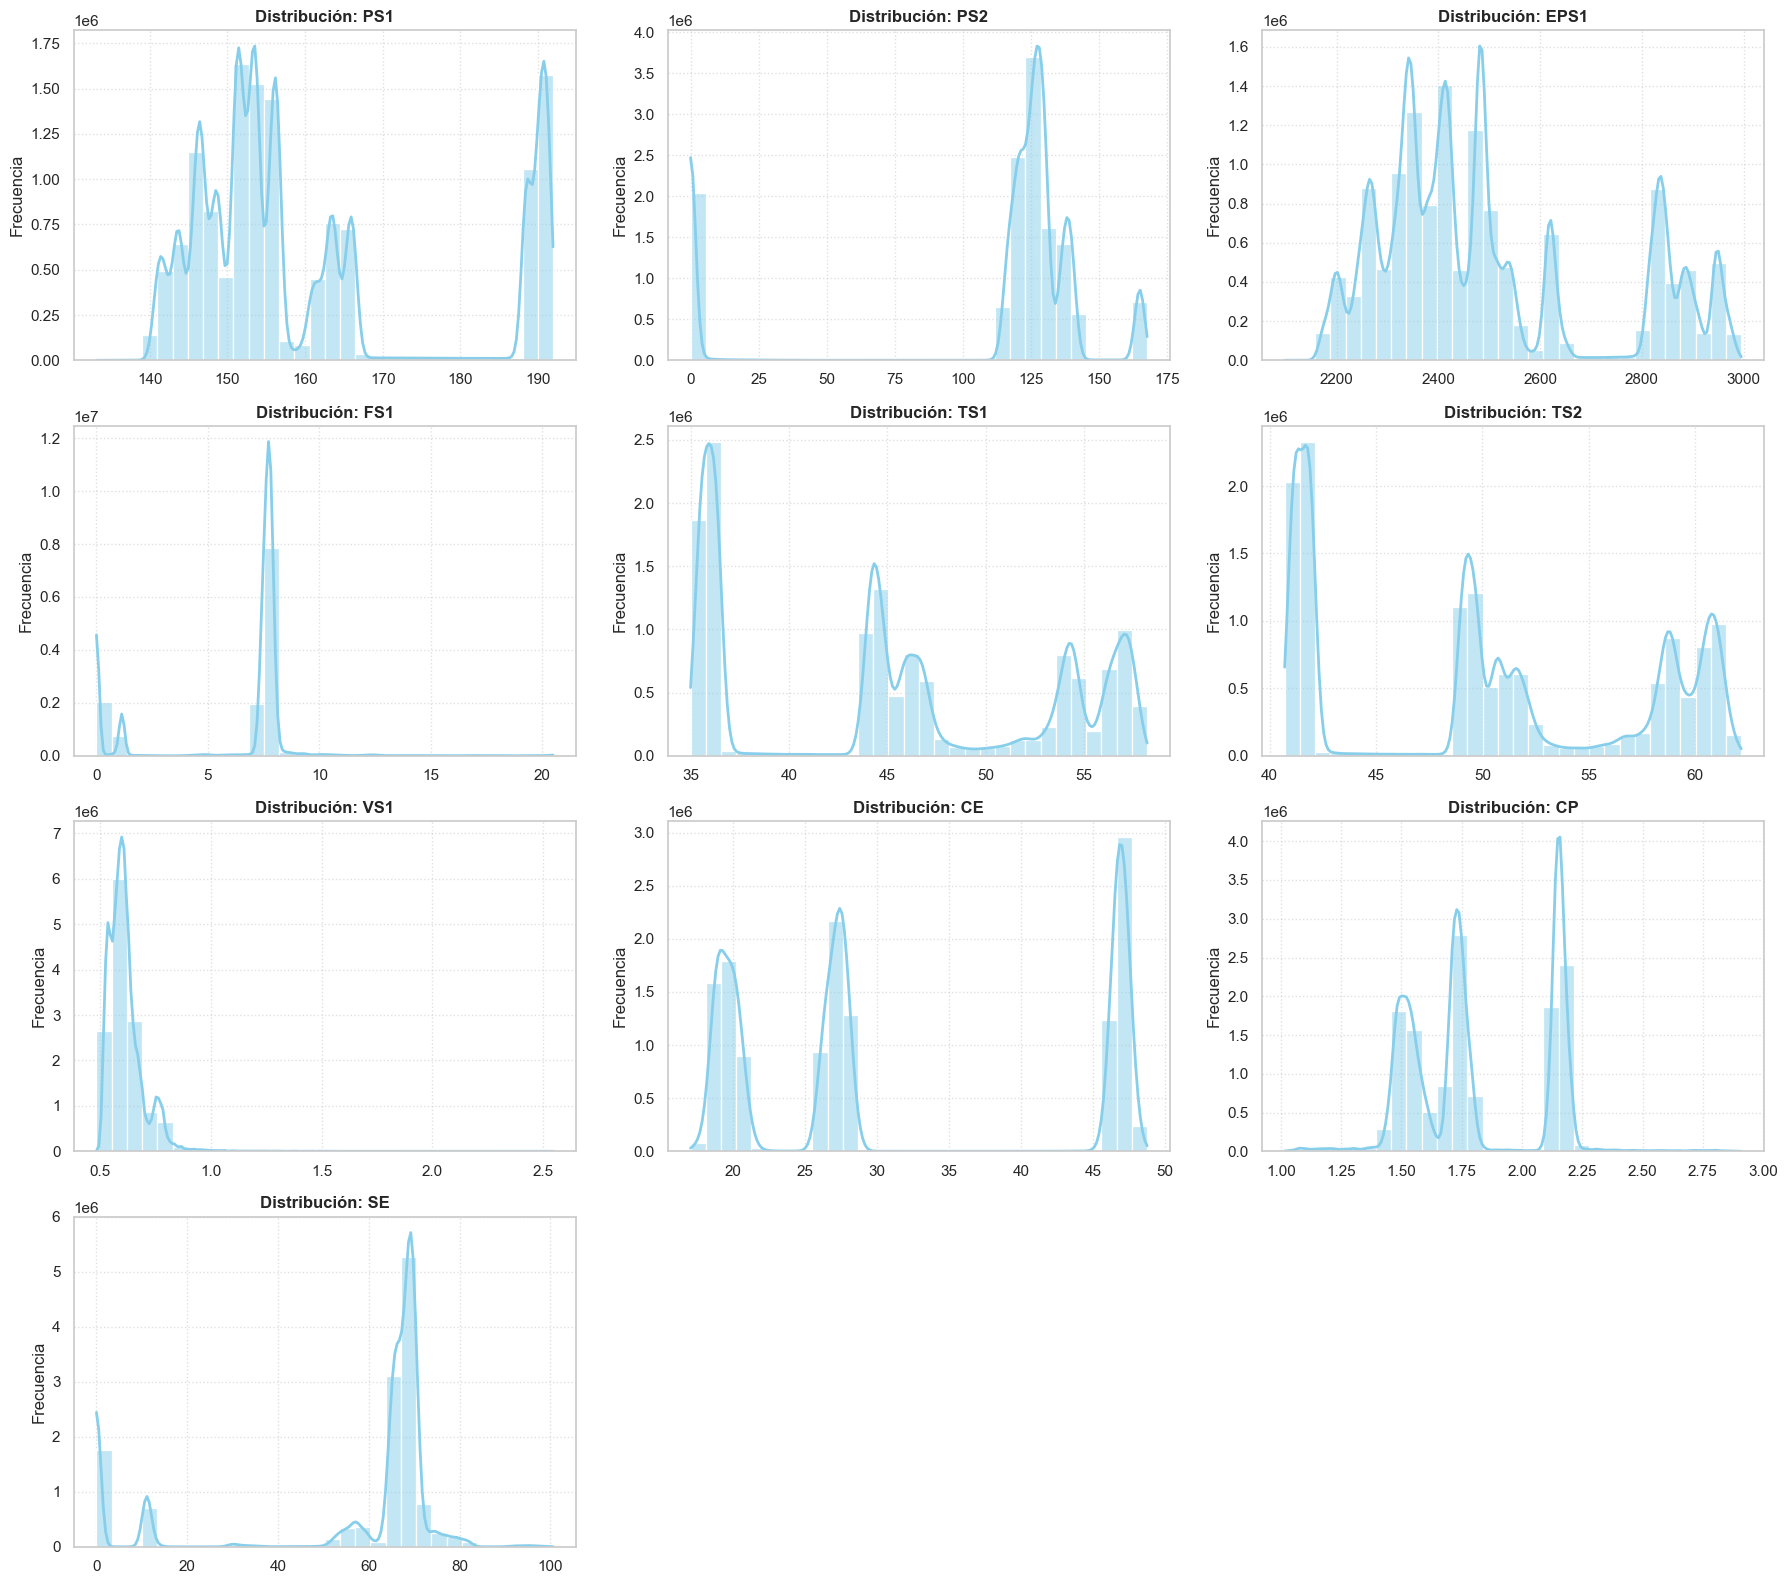

In [ ]:
# Selección de columnas (Excluyendo índices temporales)
cols_exclude = ['Cycle_ID', 'Time', 'Absolute_Time', 'date']
cols_to_plot = sensores_finales

df_dist = df.copy()
df_dist = df_dist[cols_to_plot]

# Configuración del Grid de Gráficos
n_vars = len(cols_to_plot)
n_cols = 3  # Número de columnas en el gráfico
n_rows = math.ceil(n_vars / n_cols)

fig, axes = plt.subplots(n_rows, n_cols, figsize=(18, 4 * n_rows))
axes = axes.flatten()  # Aplanar para iterar fácilmente

# Generación de los Histogramas
print(f"Generando distribuciones para {n_vars} variables...")

for i, col in enumerate(cols_to_plot):
    ax = axes[i]
    
    # Diferenciar color visualmente: Sensores (Azul) vs Targets (Verde)
    color = 'skyblue' if col in sensores_finales else 'lightgreen'
    k_color = 'navy' if col in sensores_finales else 'darkgreen'
    
    # Histograma con curva de densidad (KDE)
    sns.histplot(data=df_dist, x=col, kde=True, ax=ax, color=color, 
                 line_kws={'color': k_color, 'linewidth': 2}, bins=30)
    
    ax.set_title(f'Distribución: {col}', fontsize=12, fontweight='bold')
    ax.set_ylabel('Frecuencia')
    ax.set_xlabel('')
    ax.grid(True, linestyle=':', alpha=0.6)

# Ocultar ejes vacíos si sobran cuadros
for j in range(i + 1, len(axes)):
    fig.delaxes(axes[j])

plt.tight_layout()
plt.show()

El problema principal lo tendremos en las variables de Temperatura ya que presentan distribuciones similares, tendremos que realizar alguna variación de estas para poder observar intercambios térmicos similares a maquinaria de pasteurizado.

### **ANÁLISIS FÍSICOS**

Gracias a las relaciones físicas existentes entre las variables, vamos a realizar gráficas bidimensionales para estudiar las relaciones reales. Esto nos ayudará más tarde a introducir la parte neurosimbólica del modelo.

In [ ]:
# Calculamos variables físicas derivadas (Feature Engineering simple)
# Potencia Hidráulica estimada ~ Presión * Caudal
df['Hydraulic_Power_Est'] = df['PS1'] * df['FS1']

# Eficiencia Calculada (Potencia Salida / Potencia Entrada)
# Nota: EPS1 puede ser 0 en algún momento, sumamos un epsilon pequeño para evitar división por cero
df['Calc_Efficiency'] = df['Hydraulic_Power_Est'] / (df['EPS1'] + 1e-5)

* **1. Conservación de la Energía: Potencia Eléctrica vs. Potencia Hidráulica:** Bomba (Pump) y Fugas (Pump Leakage). La física dicta que la potencia eléctrica consumida por el motor ($P_{elec}$) se convierte en potencia hidráulica ($P_{hyd}$) con una cierta eficiencia ($\eta$).
    * Variables a relacionar:
        * Eje X: Potencia Eléctrica ($EPS1$).
        * Eje Y: Potencia Hidráulica, calculada como $P_{hyd} = \text{Presión} \times \text{Caudal}$.
    * Fórmula aproximada: $P_{hyd} \approx PS1 \times FS1$.
    * La Ecuación Física:$$EPS1 \cdot \eta = PS1 \cdot FS1$$ $$\eta = \frac{PS1 \cdot FS1}{EPS1}$$
    
Se debería observar una relación lineal fuerte.

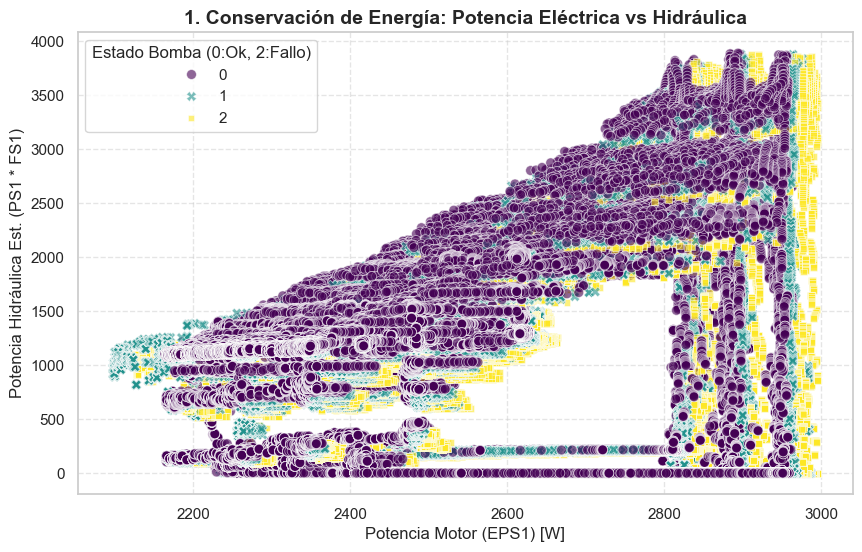

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='EPS1', y='Hydraulic_Power_Est', 
                hue='Target_Bomba', palette='viridis', style='Target_Bomba', 
                s=50, alpha=0.6)
plt.title('1. Conservación de Energía: Potencia Eléctrica vs Hidráulica', fontsize=14, fontweight='bold')
plt.xlabel('Potencia Motor (EPS1) [W]', fontsize=12)
plt.ylabel('Potencia Hidráulica Est. (PS1 * FS1)', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estado Bomba (0:Ok, 2:Fallo)')
plt.show()

* **2. Termodinámica:** Intercambio de Calor en el EnfriadorComponente afectado: Enfriador (Cooler_Condition). El enfriador disipa el calor generado por el sistema. La cantidad de calor extraído ($Q_{cooling}$) depende del caudal másico, el calor específico del aceite y el diferencial de temperatura.
    * Variables a relacionar: 
        * Eje X: Diferencia de Temperatura ($\Delta T = TS_{\text{antes}} - TS_{\text{después}}$). Probablemente $TS1$ vs $TS2$ o similar (Necestaríamos saber el tipo de cada sensor).
        * Eje Y: Potencia de Enfriamiento ($CP$ - sensor virtual) o simplemente la temperatura de retorno.
    * La Ecuación Física (Ley de Enfriamiento de Newton / Calorimetría):$$Q_{cooling} = \dot{m} \cdot c_p \cdot (T_{in} - T_{out})$$
    Donde $\dot{m}$ es proporcional a $FS1$.

Se debe observar que un enfriador sano (100) mantiene una $\Delta T$ mayor o una temperatura absoluta más baja. Un enfriador al 3% (casi fallo) mostrará que $T_{salida} \approx T_{entrada}$ (la pendiente cambia).

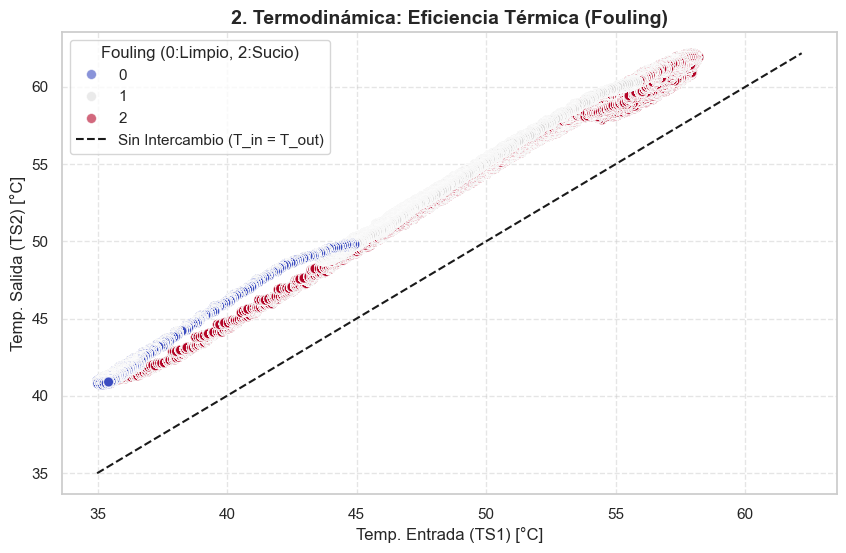

In [ ]:
plt.figure(figsize=(10, 6))
# Usamos 'Target_Fouling' en lugar de 'Cooler_Condition'
# Ojo: Target_Fouling 0 es Sano, 2 es Crítico.
sns.scatterplot(data=df, x='TS1', y='TS2', 
                hue='Target_Fouling', palette='coolwarm', s=50, alpha=0.6)

# Línea de referencia T_in = T_out (Sin intercambio)
min_val = min(df['TS1'].min(), df['TS2'].min())
max_val = max(df['TS1'].max(), df['TS2'].max())
plt.plot([min_val, max_val], [min_val, max_val], 'k--', label='Sin Intercambio (T_in = T_out)')

plt.title('2. Termodinámica: Eficiencia Térmica (Fouling)', fontsize=14, fontweight='bold')
plt.xlabel('Temp. Entrada (TS1) [°C]', fontsize=12)
plt.ylabel('Temp. Salida (TS2) [°C]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Fouling (0:Limpio, 2:Sucio)')
plt.show()

# La relación lineal existente indica consistencia entre las temperaturas

* **3. Dinámica de Fluidos:** Relación Presión-Caudal (Curva del Sistema) Componente afectado: Válvula (Valve_Condition) y Bomba. En un circuito hidráulico, la presión y el caudal están acoplados por la resistencia del sistema (la válvula).
    * Variables a relacionar:
        * Eje X: Caudal ($FS1$).
        * Eje Y: Presión del Sistema ($PS1$ o $PS2$).
    * La Ecuación Física (Ecuación de Bernoulli / Orificio):$$\Delta P = k \cdot Q^2$$ (La caída de presión es proporcional al cuadrado del caudal en flujo turbulento).
    
La Valve_Condition (especialmente el "Lag" o retraso) afecta la histéresis de este ciclo. Si la válvula es lenta, la transición entre alta presión/bajo caudal y baja presión/alto caudal se "ensancha" o se deforma en el tiempo.

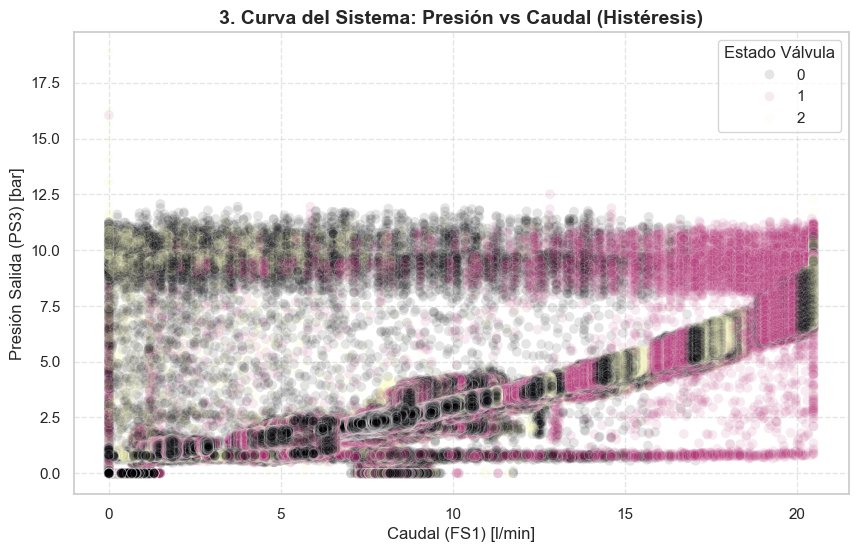

In [ ]:
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='FS1', y='PS3', 
                hue='Target_Valvula', palette='magma', s=50, alpha=0.1) # Alpha bajo porque hay muchos puntos
plt.title('3. Curva del Sistema: Presión vs Caudal (Histéresis)', fontsize=14, fontweight='bold')
plt.xlabel('Caudal (FS1) [l/min]', fontsize=12)
plt.ylabel('Presión Salida (PS3) [bar]', fontsize=12)
plt.grid(True, linestyle='--', alpha=0.5)
plt.legend(title='Estado Válvula')
plt.show()

* **4. Ley de los Gases: El Acumulador HidráulicoComponente afectado:** Acumulador (Hydraulic_Accumulator). El acumulador actúa como un resorte de gas (nitrógeno). Sigue una expansión politrópica ($P \cdot V^n = \text{constante}$). Cuando el gas se escapa (fallo), el acumulador pierde su capacidad de amortiguar y almacenar energía.
    * Variables a relacionar: Este es difícil de ver estáticamente, se ve mejor en la dinámica.
        * Eje X: Presión ($PS1$).
        * Eje Y: Tiempo (o índice dentro del ciclo).
        * Alternativa 2D: Presión ($PS1$) vs. Vibración ($VS1$).
    * La Ecuación Física (Rigidez del sistema): Un acumulador sin gas es un sistema "rígido". Un acumulador sano es "elástico".$$\frac{dP}{dt} \propto \frac{1}{V_{gas}}$$

Se debe observar la pendiente de la subida y bajada de presión. Cuando la presión del gas es baja (fallo), las curvas de presión ($PS1$) tienen picos más agudos y caídas más rápidas (menos amortiguación). En un gráfico $PS1$ vs $VS1$, un acumulador roto mostrará mucha más vibración para la misma presión debido a la falta de absorción de pulsos.

* En el paper de Helwig (I2MTC-2015), mencionan que la característica clave no es la media de presión, sino la pendiente de caída durante los ciclos de descarga.

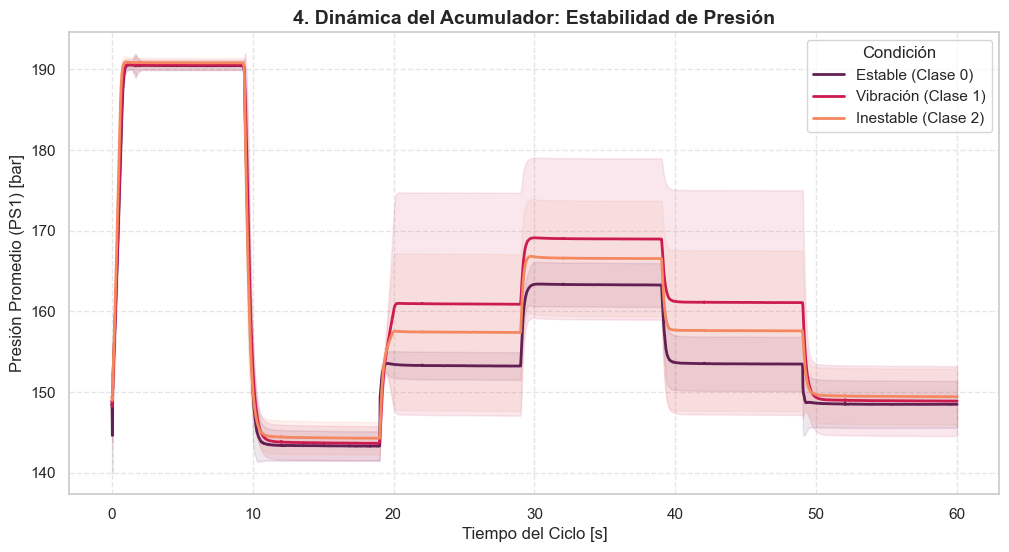

In [ ]:
# Agrupamos por Estado y Tiempo relativo
# Usamos 'Target_Acumulador' en lugar de 'Hydraulic_Accumulator'
df_profile = df.groupby(['Target_Acumulador', 'Time'])['PS1'].agg(['mean', 'std']).reset_index()

plt.figure(figsize=(12, 6))
estados = sorted(df_profile['Target_Acumulador'].unique())
colors = sns.color_palette("rocket", len(estados))

for i, estado in enumerate(estados):
    datos_estado = df_profile[df_profile['Target_Acumulador'] == estado]
    
    # Etiqueta legible
    label_text = "Estable" if estado == 0 else ("Inestable" if estado == 2 else "Vibración")
    
    plt.plot(datos_estado['Time'], datos_estado['mean'], 
             label=f'{label_text} (Clase {estado})', color=colors[i], linewidth=2)
    
    plt.fill_between(datos_estado['Time'], 
                     datos_estado['mean'] - datos_estado['std'], 
                     datos_estado['mean'] + datos_estado['std'], 
                     color=colors[i], alpha=0.1)

plt.title('4. Dinámica del Acumulador: Estabilidad de Presión', fontsize=14, fontweight='bold')
plt.xlabel('Tiempo del Ciclo [s]', fontsize=12)
plt.ylabel('Presión Promedio (PS1) [bar]', fontsize=12)
plt.legend(title="Condición")
plt.grid(True, linestyle='--', alpha=0.5)
plt.show()

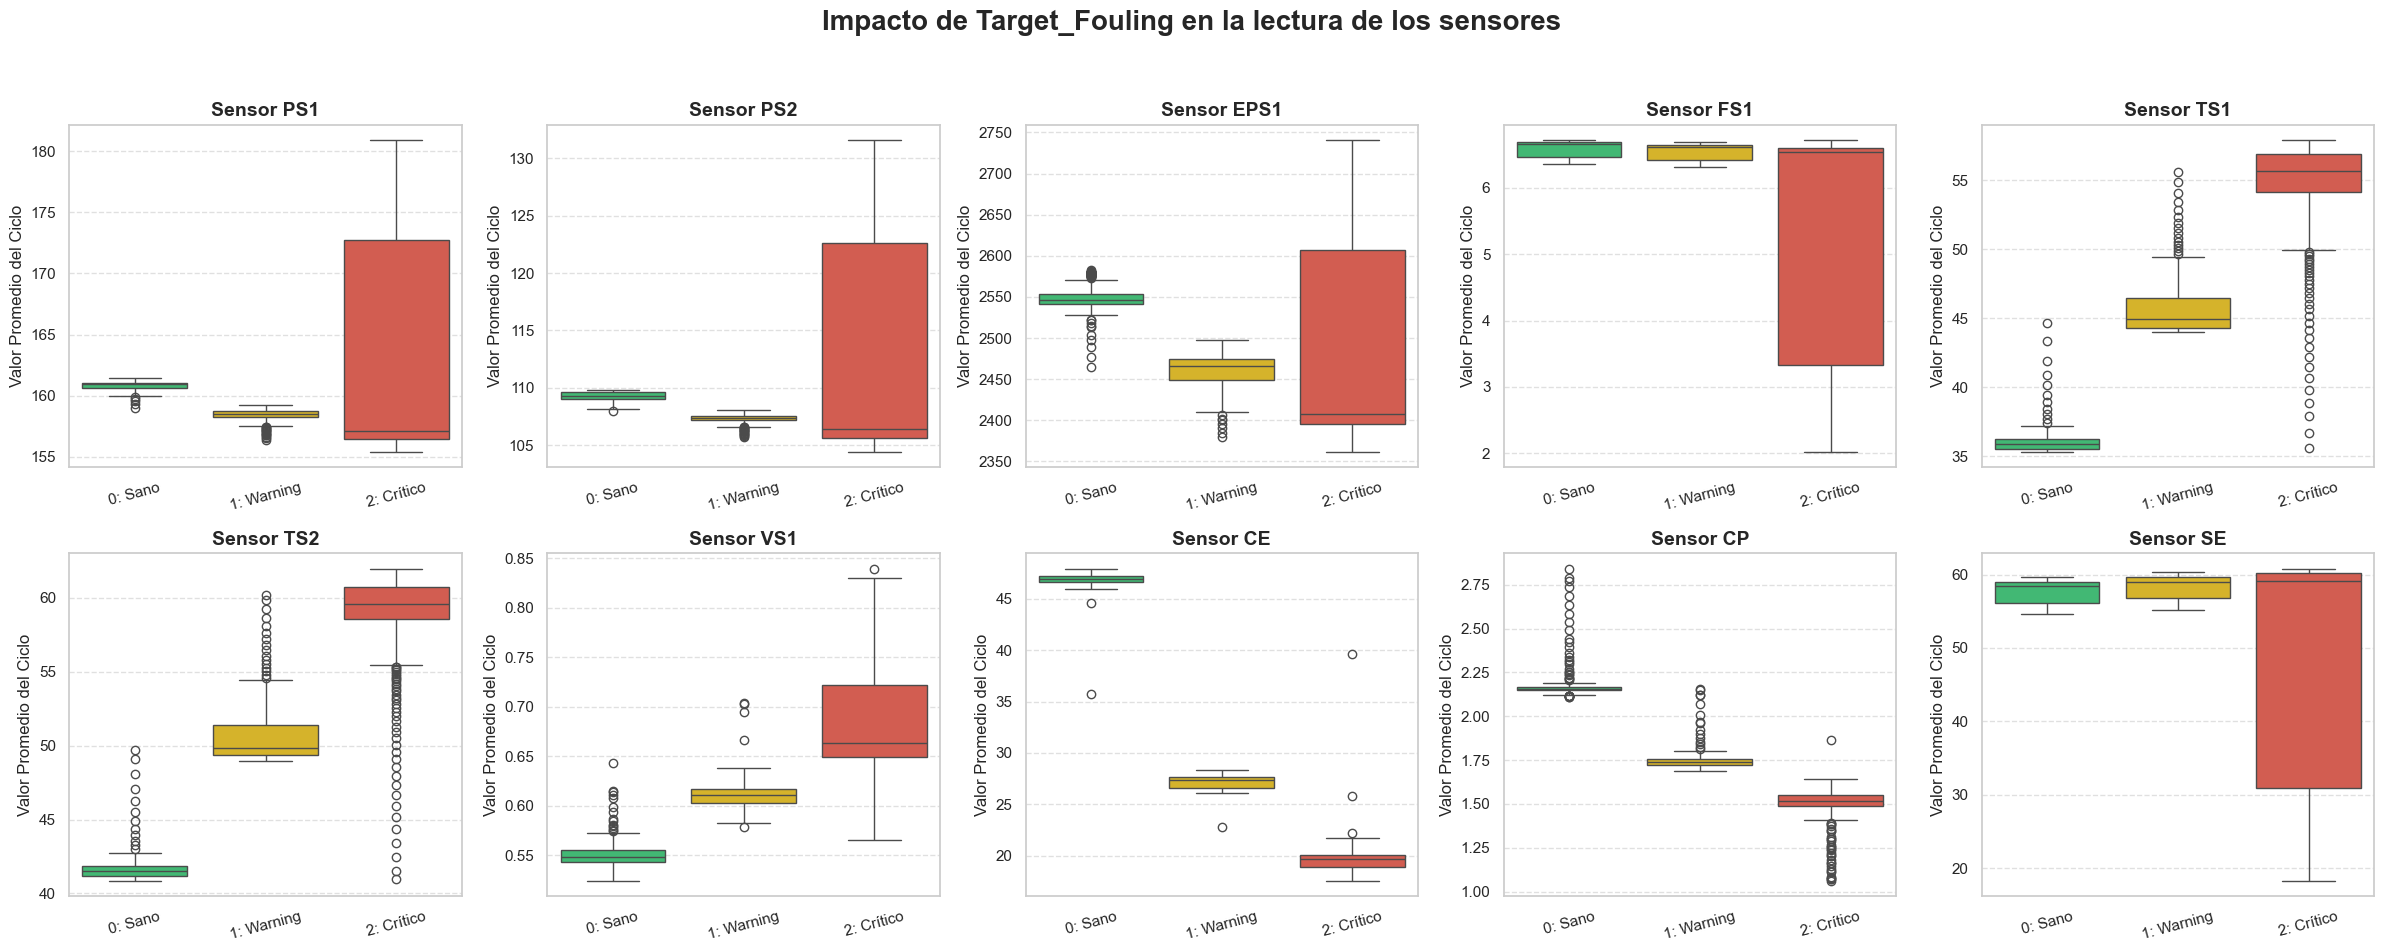

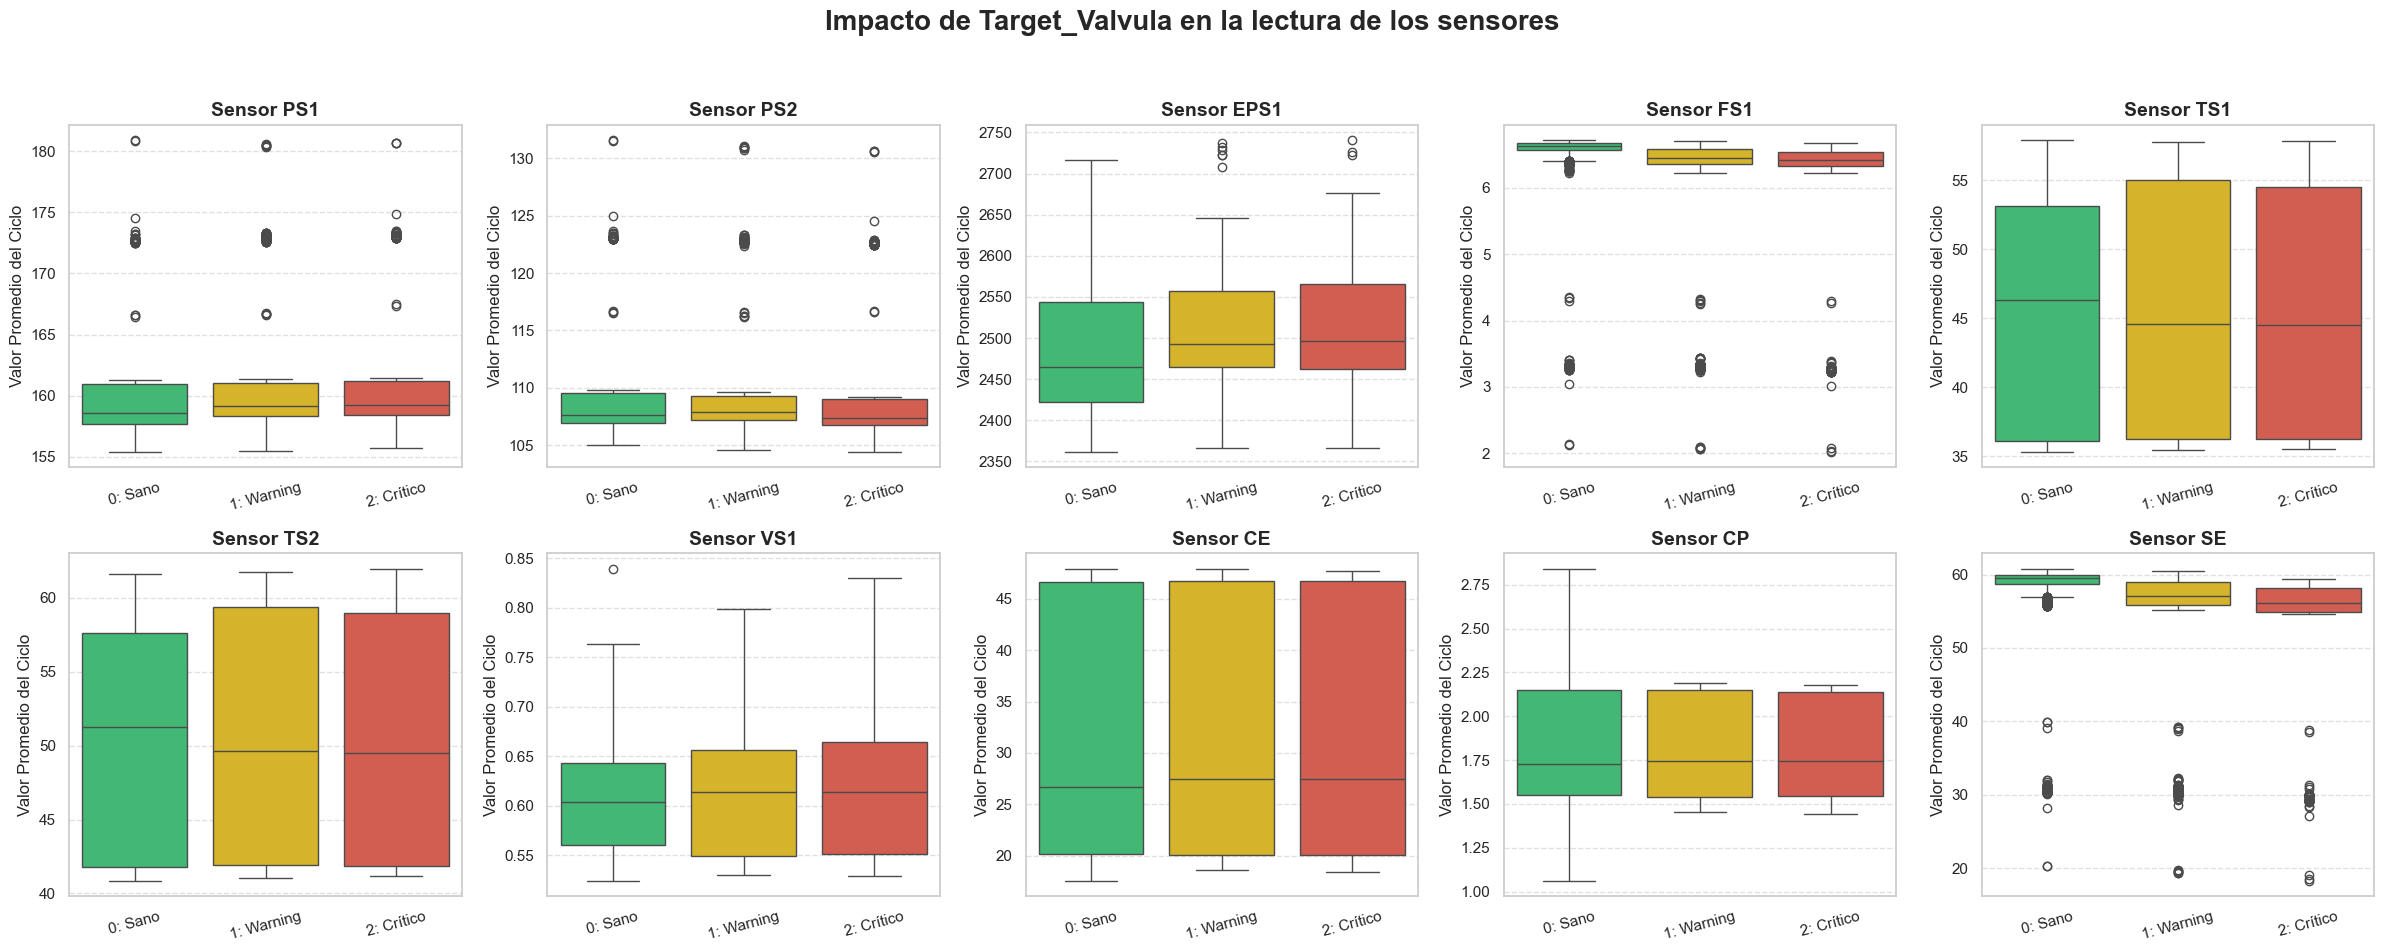

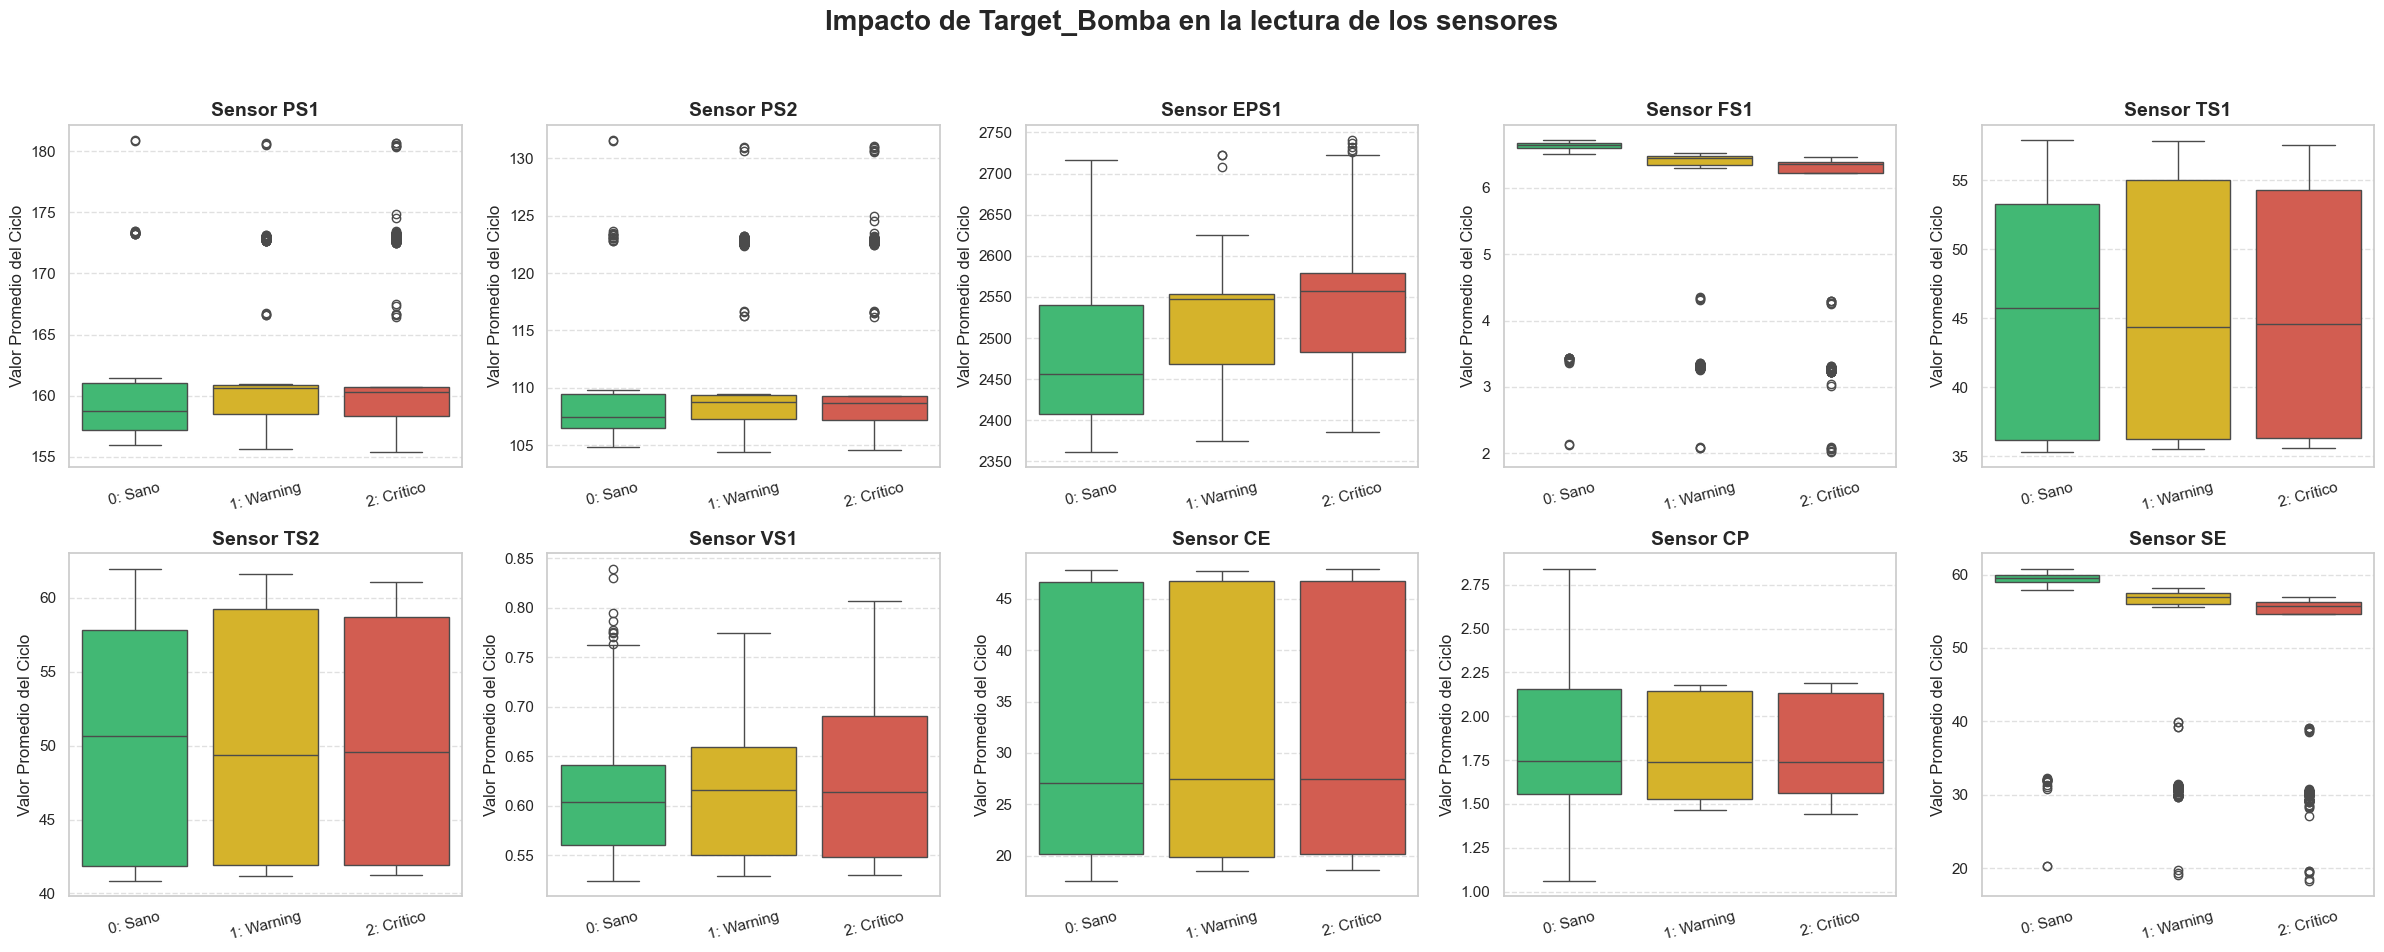

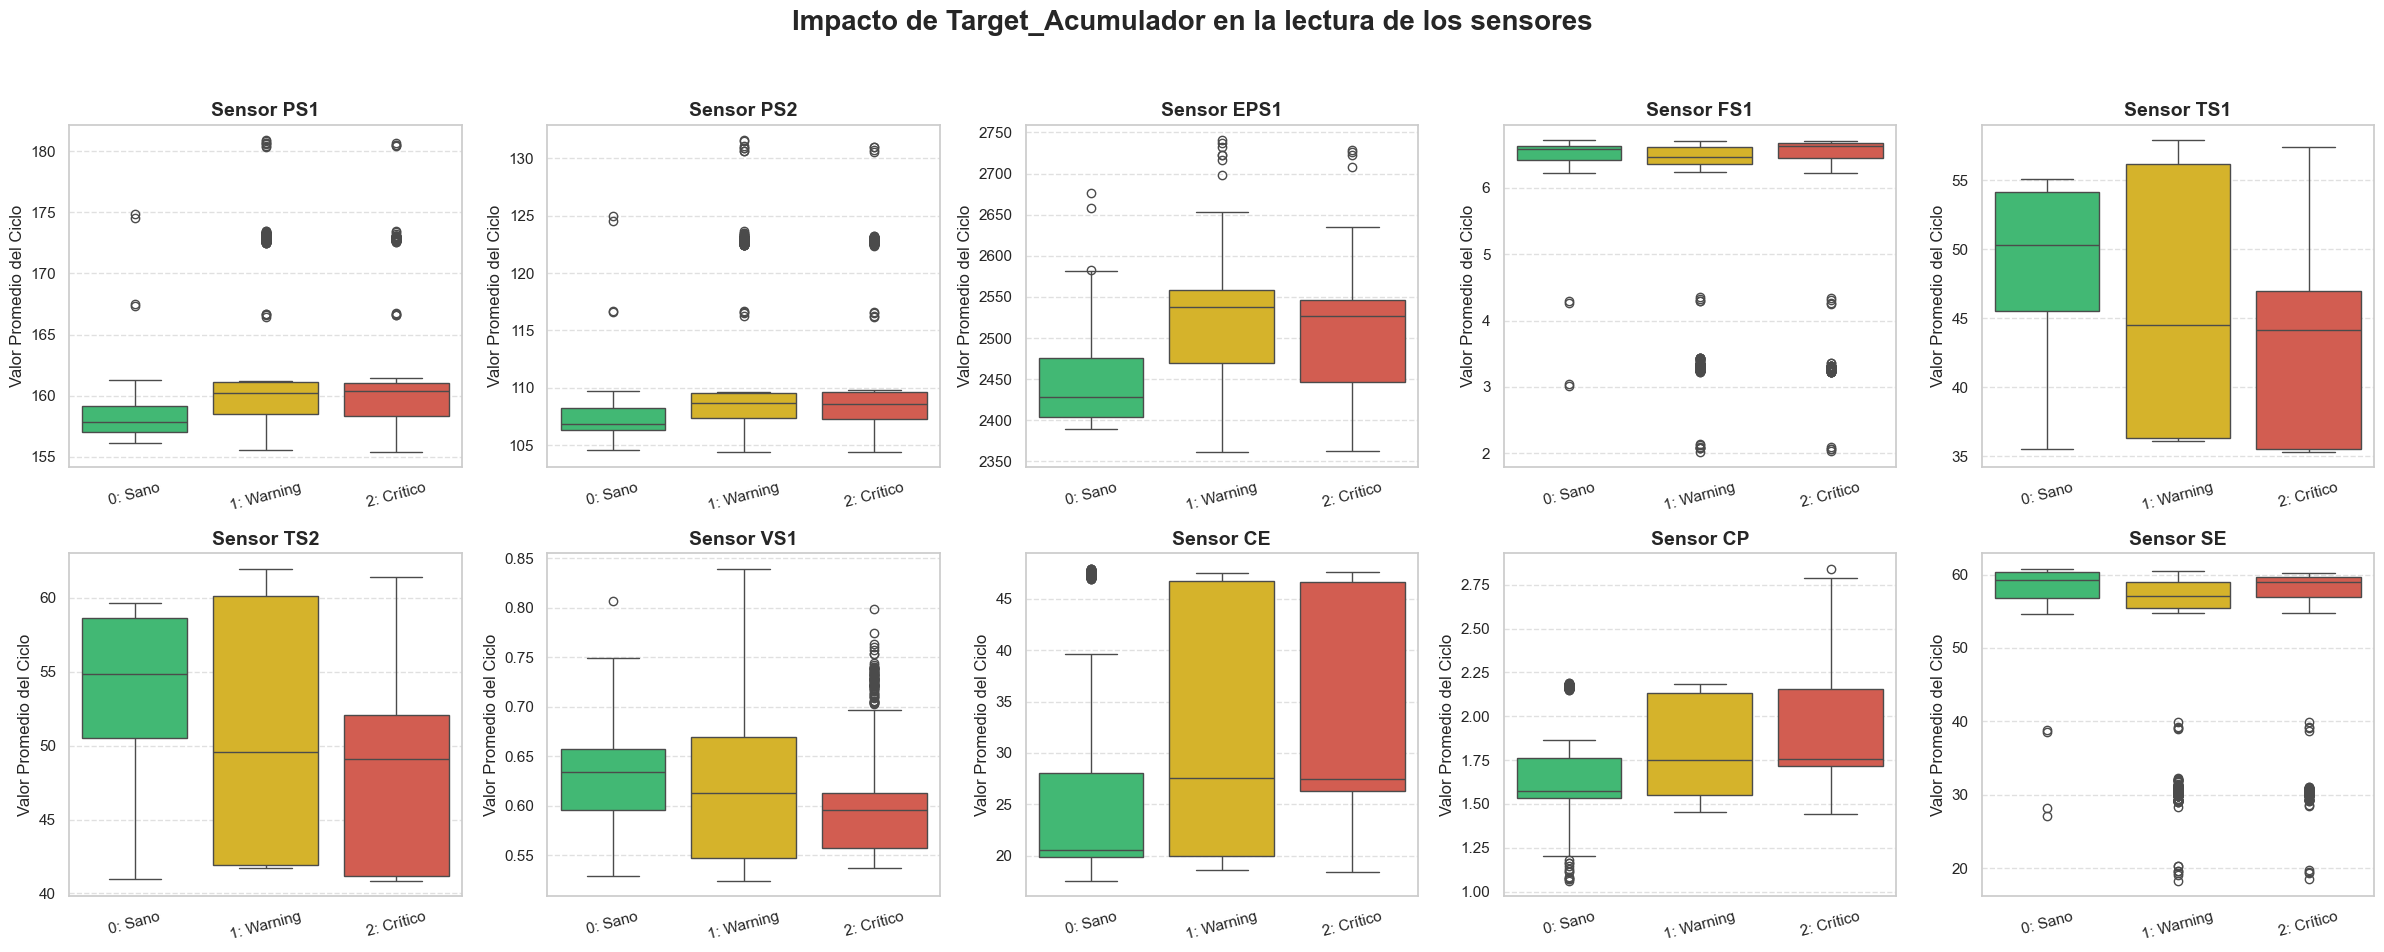

In [ ]:
# ==============================================================================
# BOXPLOTS: RELACIÓN ENTRE SENSORES Y ESTADOS DE LOS COMPONENTES
# ==============================================================================

# 1. Agrupar por ciclo para optimizar el renderizado (de 13M filas a 2205)
# Para los sensores calculamos la media del ciclo, para los targets cogemos el primer valor
agrupaciones = {sensor: 'mean' for sensor in sensores_finales}
agrupaciones.update({target: 'first' for target in targets_finales})

df_box = df.groupby('Cycle_ID').agg(agrupaciones).reset_index()

# 2. Diccionario de mapeo para que las etiquetas del gráfico sean claras
mapa_clases = {0: '0: Sano', 1: '1: Warning', 2: '2: Crítico'}

# Paleta de colores semántica (Verde=Sano, Amarillo=Warning, Rojo=Crítico)
colores_estado = ['#2ecc71', '#f1c40f', '#e74c3c']

# 3. Bucle para generar una figura completa por cada Target
for target in targets_finales:
    
    # Creamos una columna temporal con los nombres de las clases
    df_box['Estado'] = df_box[target].map(mapa_clases)
    
    # Configuramos un grid de 2 filas x 5 columnas (para los 10 sensores)
    fig, axes = plt.subplots(2, 5, figsize=(24, 10))
    axes = axes.flatten()
    
    # Título principal de la figura
    fig.suptitle(f'Impacto de {target} en la lectura de los sensores', 
                 fontsize=20, fontweight='bold', y=0.98)
    
    # Pintamos el boxplot de cada sensor
    for i, sensor in enumerate(sensores_finales):
        sns.boxplot(data=df_box, 
                    x='Estado', 
                    y=sensor, 
                    ax=axes[i], 
                    palette=colores_estado, 
                    order=['0: Sano', '1: Warning', '2: Crítico'])
        
        # Estilos del subplot
        axes[i].set_title(f'Sensor {sensor}', fontsize=14, fontweight='bold')
        axes[i].set_xlabel('')
        axes[i].set_ylabel('Valor Promedio del Ciclo')
        axes[i].grid(axis='y', linestyle='--', alpha=0.6)
        
        # Rotamos las etiquetas X para que no se superpongan
        axes[i].tick_params(axis='x', rotation=15)
        
    # Ajustamos el layout para que no choque el título principal con los gráficos
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.show()

De estas representaciones, se deduce que:

* `Target_Fouling`: Las clases de fallo se encuentran **muy separadas**, por lo que el modelo aprenderá a diferenciarlas de forma muy sencilla. Se espera que la precisión sea mucho mayor al resto de componentes.
* `Target_Valvula`, `Target_Bomba` y `Target_Acumulador`: Las clases de fallo se encuentran algo más próximas, por lo que al modelo le costará un poco más clasificarlas. Aún así, se presentan diferencias notorias, por lo que se esperan buenas predicciones también en estas componentes.